# Введение в машинное обучение, АБД

## НИУ ВШЭ, 2025-26 учебный год

# Домашнее задание 1. Часть 2. Регрессия и инференс модели

Задание выполнил(а):

    Белов Максим

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;
*  реализовать веб-сервис для применения построенной модели на новых данных

> Оценка за домашнее задание = $min(\text{ваш балл}, 33)$

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания за рамками справочной и образовательной информации генеративных моделей (ChatGPT и так далее) для генерации кода задания считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов или все баллы за соответствующее задание снимается.

## Импорт библиотек, установка констант

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd

In [2]:
CARS_TRAIN = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_train.csv'
CARS_TEST = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_test.csv'

In [3]:
RANDOM_STATE = 42

In [4]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Задание 0

Для чего фиксируем сиды в ноутбуке?

Фиксация сидов обеспечивает воспроизводимость результатов.

## Часть 1 | EDA

Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков
- Визуализации признаков и их анализ

В следующих частях вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (4.5 балла)**

In [5]:
import requests
from io import StringIO
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

CARS_TRAIN = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_train.csv'
CARS_TEST = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_test.csv'

def read_csv_secure(url):
    response = requests.get(url, verify=False)
    response.raise_for_status() 
    return pd.read_csv(StringIO(response.text))

df_train = read_csv_secure(CARS_TRAIN)
df_test = read_csv_secure(CARS_TEST)

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(1.2 балла)**
Выполните операции, направленные на базовое исследование данных:

- [ ] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [ ] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [ ] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling) (0.15 балла)
- [ ] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла)

In [6]:
df_train.info()

missing_values = df_train.isnull().sum()
missing_cols = missing_values[missing_values > 0]

missing_values_test = df_test.isnull().sum()
missing_cols_test = missing_values_test[missing_values_test > 0]

print(f"Пропуски в {len(missing_cols)} колонках train:")
for col, count in missing_cols.items():
    percentage = (count / len(df_train)) * 100
    print(f"  - {col}: {count} пропусков ({percentage:.2f}%)")


print(f"Пропуски в {len(missing_cols_test)} колонках test:")
for col, count in missing_cols_test.items():
    percentage = (count / len(df_train)) * 100 
    print(f"  - {col}: {count} пропусков ({percentage:.2f}%)")


#  ДУБЛИКАТЫ

duplicates_train = df_train.duplicated().sum()
duplicates_test = df_test.duplicated().sum()

print(f"Дубликаты в train: {duplicates_train}")
df_train = df_train.drop_duplicates()
print(f"Размер train после удаления дубликатов: {df_train.shape}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6999 non-null   object 
 1   year           6999 non-null   int64  
 2   selling_price  6999 non-null   int64  
 3   km_driven      6999 non-null   int64  
 4   fuel           6999 non-null   object 
 5   seller_type    6999 non-null   object 
 6   transmission   6999 non-null   object 
 7   owner          6999 non-null   object 
 8   mileage        6797 non-null   object 
 9   engine         6797 non-null   object 
 10  max_power      6803 non-null   object 
 11  torque         6796 non-null   object 
 12  seats          6797 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 711.0+ KB
Пропуски в 5 колонках train:
  - mileage: 202 пропусков (2.89%)
  - engine: 202 пропусков (2.89%)
  - max_power: 196 пропусков (2.80%)
  - torque: 203 пропусков (2.90%)


In [7]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df_train, title="Profiling Report")

profile.to_notebook_iframe()

C:\Users\Екатерина\AppData\Local\Temp\ipykernel_8456\3480835572.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 54.91it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
df_train.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0


### **Задание 2 (0.6 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [9]:
# 1. Числовые статистики 

print("ЧИСЛОВЫЕ ПРИЗНАКИ — TRAIN")
display(df_train.describe(include="number").round(2))


print("ЧИСЛОВЫЕ ПРИЗНАКИ — TEST")
display(df_test.describe(include="number").round(2))


# 2. Категориальные статистики 

print("КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ — TRAIN")
display(df_train.describe(include="object"))

print("КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ — TEST")
display(df_test.describe(include="object"))


# 3. Сравнение среднего и медианы

num_cols = df_train.select_dtypes(include="number").columns

comparison = pd.DataFrame({
    "train_mean":   df_train[num_cols].mean(),
    "train_median": df_train[num_cols].median(),
    "test_mean":    df_test[num_cols].mean(),
    "test_median":  df_test[num_cols].median(),
}).round(2)

# Разрыв mean vs median — индикатор скошенности распределения
comparison["train_%"] = ((comparison["train_mean"] - comparison["train_median"])
    / comparison["train_median"] * 100 ).round(2)

comparison["train_vs_test_%"] = ((comparison["train_mean"] - comparison["test_mean"])
    / comparison["test_mean"] * 100 ).round(2)

comparison["train_test_mean"] = abs(comparison["train_mean"] - comparison["test_mean"])

comparison["train_test_median"] = abs(comparison["train_median"] - comparison["test_median"])

comparison["train_median"] = abs(comparison["train_median"] - comparison["train_mean"])

comparison["test_median"] = abs(comparison["test_median"] - comparison["test_mean"])

print("СРАВНЕНИЕ СРЕДНЕГО И МЕДИАНЫ")
display(comparison)

ЧИСЛОВЫЕ ПРИЗНАКИ — TRAIN


,year,selling_price,km_driven,seats
count,6014.00,6014.00,6014.00,5824.00
mean,2013.45,521982.03,73764.15,5.44
std,4.08,533842.62,59610.75,0.99
min,1983.00,29999.00,1.00,2.00
25%,2011.00,250000.00,39000.00,5.00
50%,2014.00,409999.00,70000.00,5.00
75%,2017.00,640000.00,100000.00,5.00
max,2020.00,10000000.00,2360457.00,14.00


ЧИСЛОВЫЕ ПРИЗНАКИ — TEST


,year,selling_price,km_driven,seats
count,1000.00,1000.00,1000.00,981.00
mean,2013.68,617901.04,71393.34,5.41
std,4.01,758553.86,48486.22,0.92
min,1995.00,31000.00,1303.00,4.00
25%,2011.00,250000.00,37000.00,5.00
50%,2014.00,434999.00,61500.00,5.00
75%,2017.00,670000.00,100000.00,5.00
max,2020.00,6000000.00,375000.00,9.00


КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ — TRAIN


,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,6014,6014,6014,6014,6014,5824,5824,5827,5823
unique,1924,4,3,2,5,386,120,316,419
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,107,3269,5394,5505,3721,184,795,282,417


КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ — TEST


,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,1000,1000,1000,1000,1000,981,981,981,981
unique,621,4,3,2,5,237,88,182,226
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner,18.6 kmpl,1248 CC,74 bhp,200Nm@ 1750rpm
freq,15,534,837,877,623,23,116,43,57


СРАВНЕНИЕ СРЕДНЕГО И МЕДИАНЫ


,train_mean,train_median,test_mean,test_median,train_%,train_vs_test_%,train_test_mean,train_test_median
year,2013.45,0.55,2013.68,0.32,-0.03,-0.01,0.23,0.0
selling_price,521982.03,111983.03,617901.04,182902.04,27.31,-15.52,95919.01,25000.0
km_driven,73764.15,3764.15,71393.34,9893.34,5.38,3.32,2370.81,8500.0
seats,5.44,0.44,5.41,0.41,8.80,0.55,0.03,0.0


### **Задание 3 (0.6 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.05 балла)
- [ ] Отобразите такие объекты (0.05 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.05 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.05 балла)

In [10]:
# 1. Дубликаты по признакам (без целевой переменной) 

target = "selling_price"
feature_cols = [col for col in df_train.columns if col != target]

mask_duplicated = df_train.duplicated(subset=feature_cols, keep=False)
n_duplicates = mask_duplicated.sum()

print(f"Объектов с одинаковым признаковым описанием: {n_duplicates}")


# 2. Отобразить такие объекты 

display( df_train[mask_duplicated].sort_values(feature_cols) )


# 3. Удалить повторяющиеся строки

df_train = df_train.drop_duplicates(subset=feature_cols, keep="first")

print(f"Размер train после удаления: {df_train.shape}")


# 4. Обновить индекс 

df_train = df_train.reset_index(drop=True)

print(f"Индексы от {df_train.index.min()} до {df_train.index.max()}, "
      f"всего {len(df_train)} строк")

Объектов с одинаковым признаковым описанием: 338


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
124,BMW X4 M Sport X xDrive20d,2019,5800000,7500,Diesel,Dealer,Automatic,First Owner,16.78 kmpl,1995 CC,190 bhp,400Nm@ 1750-2500rpm,5.0
370,BMW X4 M Sport X xDrive20d,2019,5400000,7500,Diesel,Dealer,Automatic,First Owner,16.78 kmpl,1995 CC,190 bhp,400Nm@ 1750-2500rpm,5.0
447,Chevrolet Beat Diesel LT,2012,220000,70000,Diesel,Individual,Manual,Second Owner,25.44 kmpl,936 CC,57.6 bhp,150Nm@ 1750rpm,5.0
766,Chevrolet Beat Diesel LT,2012,200000,70000,Diesel,Individual,Manual,Second Owner,25.44 kmpl,936 CC,57.6 bhp,150Nm@ 1750rpm,5.0
4704,Chevrolet Beat Diesel LT,2012,165000,70000,Diesel,Individual,Manual,Second Owner,25.44 kmpl,936 CC,57.6 bhp,150Nm@ 1750rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5262,Volkswagen Polo 1.2 MPI Comfortline,2016,395000,40000,Petrol,Individual,Manual,Second Owner,16.2 kmpl,1199 CC,74 bhp,110Nm@ 3000-4300rpm,5.0
5263,Volkswagen Polo 1.2 MPI Comfortline,2016,385000,40000,Petrol,Individual,Manual,Second Owner,16.2 kmpl,1199 CC,74 bhp,110Nm@ 3000-4300rpm,5.0
467,Volkswagen Vento Diesel Highline,2012,450000,90000,Diesel,Individual,Manual,First Owner,20.54 kmpl,1598 CC,103.6 bhp,250Nm@ 1500-2500rpm,5.0
2244,Volkswagen Vento Diesel Highline,2012,375000,90000,Diesel,Individual,Manual,First Owner,20.54 kmpl,1598 CC,103.6 bhp,250Nm@ 1500-2500rpm,5.0


Размер train после удаления: (5840, 13)
Индексы от 0 до 5839, всего 5840 строк


In [11]:
print(df_train.shape)
print(df_train.columns.tolist())

(5840, 13)
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']


In [12]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.6 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными, они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [13]:
import re

def extract_number(value):
    if pd.isna(value):
        return np.nan    
    match = re.search(r'\d+\.?\d*', str(value))
    if match:
        return float(match.group())
    return np.nan

# 1. Очистка mileage ("kmpl", "km/kg")
print("До очистки mileage:")
print(df_train['mileage'].head(10))

df_train['mileage'] = df_train['mileage'].apply(extract_number)
df_test['mileage'] = df_test['mileage'].apply(extract_number)

print("\nПосле очистки mileage:")
print(df_train['mileage'].head(10))
print(f"Тип данных: {df_train['mileage'].dtype}")

# 2. Очистка engine ("CC")
print("До очистки engine:")
print(df_train['engine'].head(10))

df_train['engine'] = df_train['engine'].apply(extract_number)
df_test['engine'] = df_test['engine'].apply(extract_number)

print("\nПосле очистки engine:")
print(df_train['engine'].head(10))
print(f"Тип данных: {df_train['engine'].dtype}")

# 3. Очистка max_power ("bhp")
print("До очистки max_power:")
print(df_train['max_power'].head(10))

df_train['max_power'] = df_train['max_power'].apply(extract_number)
df_test['max_power'] = df_test['max_power'].apply(extract_number)

print("\nПосле очистки max_power:")
print(df_train['max_power'].head(10))
print(f"Тип данных: {df_train['max_power'].dtype}")


До очистки mileage:
0     23.4 kmpl
1    21.14 kmpl
2     23.0 kmpl
3     16.1 kmpl
4    20.14 kmpl
5    17.3 km/kg
6     16.1 kmpl
7    23.59 kmpl
8     20.0 kmpl
9    19.01 kmpl
Name: mileage, dtype: object

После очистки mileage:
0    23.40
1    21.14
2    23.00
3    16.10
4    20.14
5    17.30
6    16.10
7    23.59
8    20.00
9    19.01
Name: mileage, dtype: float64
Тип данных: float64
До очистки engine:
0    1248 CC
1    1498 CC
2    1396 CC
3    1298 CC
4    1197 CC
5    1061 CC
6     796 CC
7    1364 CC
8    1399 CC
9    1461 CC
Name: engine, dtype: object

После очистки engine:
0    1248.0
1    1498.0
2    1396.0
3    1298.0
4    1197.0
5    1061.0
6     796.0
7    1364.0
8    1399.0
9    1461.0
Name: engine, dtype: float64
Тип данных: float64
До очистки max_power:
0        74 bhp
1    103.52 bhp
2        90 bhp
3      88.2 bhp
4     81.86 bhp
5      57.5 bhp
6        37 bhp
7      67.1 bhp
8      68.1 bhp
9    108.45 bhp
Name: max_power, dtype: object

После очистки max_power:

In [ ]:
# сначала попробую переиспользовать extract_number который уже написал, он вытаскивает первое число из строки

df_train['torque_test'] = df_train['torque'].apply(extract_number)

print('первые значения torque:')
print(df_train['torque'].head())
print()
print('после extract_number:')
print(df_train['torque_test'].head())


первые значения torque:
0              190Nm@ 2000rpm
1         250Nm@ 1500-2500rpm
2    22.4 kgm at 1750-2750rpm
3       11.5@ 4,500(kgm@ rpm)
4           113.75nm@ 4000rpm
Name: torque, dtype: object

после extract_number:
0    190.00
1    250.00
2     22.40
3     11.50
4    113.75
Name: torque_test, dtype: float64


In [16]:
# '22.4 kgm at 1750-2750rpm' => extract_number даст 22.4, но это неправильно -- kgm нужно переводить в Nm

test_vals = [
    '22.4 kgm at 1750-2750rpm',
    '11.5@ 4,500(kgm@ rpm)',
]
for v in test_vals:
    print(f"строка: '{v}'  =>  torque={extract_number(v)}")

print()
print(f'22.4 kgm = {22.4 * 9.80665:.2f} Nm')
print(f'11.5 kgm = {11.5 * 9.80665:.2f} Nm')


строка: '22.4 kgm at 1750-2750rpm'  =>  torque=22.4
строка: '11.5@ 4,500(kgm@ rpm)'  =>  torque=11.5

22.4 kgm = 219.67 Nm
11.5 kgm = 112.78 Nm


In [17]:
print('уникальные форматы torque (первые 30):')
for v in df_train['torque'].dropna().unique()[:30]:
    print(f"  '{v}'")

уникальные форматы torque (первые 30):
  '190Nm@ 2000rpm'
  '250Nm@ 1500-2500rpm'
  '22.4 kgm at 1750-2750rpm'
  '11.5@ 4,500(kgm@ rpm)'
  '113.75nm@ 4000rpm'
  '7.8@ 4,500(kgm@ rpm)'
  '59Nm@ 2500rpm'
  '170Nm@ 1800-2400rpm'
  '160Nm@ 2000rpm'
  '248Nm@ 2250rpm'
  '78Nm@ 4500rpm'
  '84Nm@ 3500rpm'
  '115Nm@ 3500-3600rpm'
  '62Nm@ 3000rpm'
  '219.7Nm@ 1500-2750rpm'
  '200Nm@ 1750rpm'
  '115Nm@ 4000rpm'
  '69Nm@ 3500rpm'
  '172.5Nm@ 1750rpm'
  '6.1kgm@ 3000rpm'
  '60Nm@ 3500rpm'
  '90Nm@ 3500rpm'
  '151Nm@ 4850rpm'
  '104Nm@ 4000rpm'
  '320Nm@ 1700-2700rpm'
  '250Nm@ 1750-2500rpm'
  '145Nm@ 4600rpm'
  '146Nm@ 4800rpm'
  '343Nm@ 1400-3400rpm'
  '200Nm@ 1400-3400rpm'


In [18]:
# 4. Очистка колонки torque

def extract_torque_and_rpm(value):
    if pd.isna(value):
        return np.nan, np.nan
    
    value_str = str(value).strip()
    
    # Приведём к верхнему регистру
    value_upper = value_str.upper()
    
    torque_value = np.nan
    rpm_value = np.nan
    
    # Обработка разных случаев
    # 1. 190Nm@ 2000rpm / 190 Nm at 2000 rpm
    match = re.search(r'([\d,.]+)\s*(?:NM|N M)', value_upper)
    if match:
        torque_value = float(match.group(1).replace(',', ''))
    
    # 2. 24 KGM at 1900-2750 RPM / 6.1kgm@ 3000rpm
    if pd.isna(torque_value):
        match = re.search(r'([\d,.]+)\s*(?:KGM|KG M)', value_upper)
        if match:
            # Конвертируем kgm в Nm (1 kgm = 9.80665 Nm)
            torque_value = float(match.group(1).replace(',', '')) * 9.80665
    
    # 3. 11.5@ 4,500(kgm@ rpm) 
    if pd.isna(torque_value):
        match = re.search(r'([\d,.]+)\s*@.*?\(KGM', value_upper)
        if match:
            torque_value = float(match.group(1).replace(',', '')) * 9.80665
    
    # 4. 250@ 1250-5000rpm 
    if pd.isna(torque_value):
        match = re.search(r'^([\d,.]+)\s*@', value_upper)
        if match:
            torque_value = float(match.group(1).replace(',', ''))
    
    # 5. 400Nm
    if pd.isna(torque_value):
        match = re.search(r'([\d,.]+)\s*NM\s*$', value_upper)
        if match:
            torque_value = float(match.group(1).replace(',', ''))
    
    # 6. 510@ 1600-2400 
    if pd.isna(torque_value):
        match = re.search(r'^([\d,.]+)\s*@\s*[\d]', value_upper)
        if match and 'RPM' not in value_upper:
            torque_value = float(match.group(1).replace(',', ''))
    
    # 7. 210 / 1900 
    if pd.isna(torque_value):
        match = re.search(r'([\d,.]+)\s*/\s*[\d]', value_upper)
        if match:
            torque_value = float(match.group(1).replace(',', ''))


    rpm_patterns = [
        r'@\s*[\d,]+[-~][\d,]+',  # @ 1500-2500
        r'AT\s*[\d,]+[-~][\d,]+', # at 1500-2500
        r'@\s*[\d,]+',             # @ 2000
        r'AT\s*[\d,]+',            # at 2000
        r'/\s*[\d,]+',             # / 1900
    ]
    
    for pattern in rpm_patterns:
        match = re.search(pattern, value_upper)
        if match:
            rpm_str = match.group()
            numbers = re.findall(r'[\d,]+', rpm_str)
            if numbers:
                # последнее число
                rpm_value = float(numbers[-1].replace(',', ''))
                break
    
    # Числа с rpm
    if pd.isna(rpm_value):
        match = re.search(r'([\d,]+)\s*[-~]\s*([\d,]+)\s*RPM', value_upper)
        if match:
            rpm_value = float(match.group(2).replace(',', ''))
        else:
            match = re.search(r'([\d,]+)\s*RPM', value_upper)
            if match:
                rpm_value = float(match.group(1).replace(',', ''))
    
    return torque_value, rpm_value


# Применяем функцию к train и test
df_train[['torque', 'max_torque_rpm']] = df_train['torque'].apply(
    lambda x: pd.Series(extract_torque_and_rpm(x)))

df_test[['torque', 'max_torque_rpm']] = df_test['torque'].apply(
    lambda x: pd.Series(extract_torque_and_rpm(x)))


print("Итого")

print("\nПервые 20 строк после преобразования:")
display(df_train[['torque', 'max_torque_rpm']].head(20))

print("\nСтатистика новых колонок:")
print(df_train[['torque', 'max_torque_rpm']].describe())

print(f"\nПропуски в torque: {df_train['torque'].isnull().sum()} ({df_train['torque'].isnull().mean()*100:.2f}%)")
print(f"Пропуски в max_torque_rpm: {df_train['max_torque_rpm'].isnull().sum()} ({df_train['max_torque_rpm'].isnull().mean()*100:.2f}%)")

# Проверка на парсинг
not_parsed = df_train[df_train['torque'].isnull() & df_train['max_torque_rpm'].isnull()]
if len(not_parsed) > 0:
    print(f"\n Не удалось распарсить {len(not_parsed)} значений:")


Итого

Первые 20 строк после преобразования:


,torque,max_torque_rpm
0,190.000000,2000.0
1,250.000000,2500.0
2,219.668960,2750.0
3,112.776475,4500.0
4,113.750000,4000.0
5,76.491870,4500.0
6,59.000000,2500.0
7,170.000000,2400.0
8,160.000000,2000.0
9,248.000000,2250.0



Статистика новых колонок:
            torque  max_torque_rpm
count  5653.000000      5650.00000
mean    175.865464      3047.32885
std     108.866201       926.19434
min      47.071920      1400.00000
25%     111.700000      2250.00000
50%     160.000000      3000.00000
75%     200.055660      4000.00000
max    1863.263500     21800.00000

Пропуски в torque: 187 (3.20%)
Пропуски в max_torque_rpm: 190 (3.25%)

 Не удалось распарсить 187 значений:


### **Задание 5 (0.6 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [ ] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [ ] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`


In [126]:
df_train.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,5840.000000,5.840000e+03,5.840000e+03,5654.000000,5654.000000,5656.000000,5653.000000,5654.00000,5650.00000
mean,2013.428425,5.229601e+05,7.395224e+04,19.432842,1435.418111,88.103070,175.865464,5.44075,3047.32885
std,4.095622,5.354320e+05,6.007114e+04,4.051002,492.453262,32.131943,108.866201,0.99527,926.19434
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,47.071920,2.00000,1400.00000
25%,2011.000000,2.500000e+05,3.900000e+04,16.800000,1197.000000,68.000000,111.700000,5.00000,2250.00000
50%,2014.000000,4.050000e+05,7.000000e+04,19.370000,1248.000000,81.860000,160.000000,5.00000,3000.00000
75%,2017.000000,6.400000e+05,1.000000e+05,22.320000,1498.000000,100.000000,200.055660,5.00000,4000.00000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,1863.263500,14.00000,21800.00000


In [127]:
# 1. Расчёт медиан

num_cols = df_train.select_dtypes(include="number").columns.tolist()
num_cols = [col for col in num_cols if col != "selling_price"]

train_medians = df_train[num_cols].median()

print("Медианы (считаем по train):")
print(train_medians.round(2))


# 2. Заполняем пропуски 

df_train[num_cols] = df_train[num_cols].fillna(train_medians)
df_test[num_cols]  = df_test[num_cols].fillna(train_medians)  


# 3. Проверка

print("\nПропуски в train после заполнения:")
missing_after_train = df_train.isnull().sum()
print(missing_after_train[missing_after_train > 0] if missing_after_train.any() else "  Пропусков нет +")

print("\nПропуски в test после заполнения:")
missing_after_test = df_test.isnull().sum()
print(missing_after_test[missing_after_test > 0] if missing_after_test.any() else "  Пропусков нет +")

Медианы (считаем по train):
year               2014.00
km_driven         70000.00
mileage              19.37
engine             1248.00
max_power            81.86
torque              160.00
seats                 5.00
max_torque_rpm     3000.00
dtype: float64

Пропуски в train после заполнения:
  Пропусков нет +

Пропуски в test после заполнения:
  Пропусков нет +


In [128]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5840 entries, 0 to 5839
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            5840 non-null   object 
 1   year            5840 non-null   int64  
 2   selling_price   5840 non-null   int64  
 3   km_driven       5840 non-null   int64  
 4   fuel            5840 non-null   object 
 5   seller_type     5840 non-null   object 
 6   transmission    5840 non-null   object 
 7   owner           5840 non-null   object 
 8   mileage         5840 non-null   float64
 9   engine          5840 non-null   float64
 10  max_power       5840 non-null   float64
 11  torque          5840 non-null   float64
 12  seats           5840 non-null   float64
 13  max_torque_rpm  5840 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 638.9+ KB


Ответ на вопросы: 
1. Медиану для заполнения считаем по тренировочным данным для `train` и `test`
т.к. иначе 1. произойдет утечка данных, а 2. если считать по тестовым свою, то это нарушает честную оценку -- на инференсе мы не знаем статистики

2. Применять стоит именно медиану, т.к. она более устойчива к выбросам. Например, если какой-то 1 автомобиль стоит 10 млн, а большинтво остальных авто находятся по стоимости в пределах 1-2 млн, то медиана будет отражать стоимость большинства авто, а среднее сдвинется в большую сторону.

### **Задание 6 (0.6 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.
- [ ] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [129]:
df_train['engine'] = df_train['engine'].astype(int)
df_train['seats'] = df_train['seats'].astype(int)

# Для test
df_test['engine'] = df_test['engine'].astype(int)
df_test['seats'] = df_test['seats'].astype(int)

# Проверка
print(f"engine: {df_train['engine'].dtype}")
print(f"seats: {df_train['seats'].dtype}")

engine: int32
seats: int32


In [130]:
df_train['seats'].unique()

array([ 5,  4,  7,  8,  6,  9, 10, 14,  2])

Ответ: seats можно рассмотреть как категориальную переменную, потомучто 
1. она не является непрерывной, значения дискретные
2. Не может быть в машине 5,5 сидений, как и в категориальных признаках у нас есть только фиксированные, неизменяемые значения.

### **Задание 7 (0.3 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [131]:
df_train.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.430841,1429.448973,87.906371,175.357443,5.426712,3045.789041
std,4.095622,5.354320e+05,6.007114e+04,3.985973,485.662834,31.640418,107.145160,0.982344,911.039323
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,47.071920,2.000000,1400.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,111.800000,5.000000,2250.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.370000,1248.000000,81.860000,160.000000,5.000000,3000.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,200.055660,5.000000,4000.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,1863.263500,14.000000,21800.000000


Сдвига практически нет — медианы не изменились, средние изменились совсем незначительно (в перделах 1%)
Почему распределения не сдвинулись:
1. Пропусков было мало — около 3% (5654 из 5840). Новые значения не смогли существенно повлиять на распределение.
2. Медиана по определению попадает в центр распределения. Поэтому когда мы добавляем в датасет медианные значения, то они глобально не влияют на распределение.
Теоретически сдвиг мог бы возникнуть, если бы пропуски были не случайными — например, mileage не указывают только у новых авто с пробегом 0. Тогда медиана по всем авто завысила бы значение для этой группы. 

## **Визуализации и корреляция (4.8 балла + 0.3)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (1.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

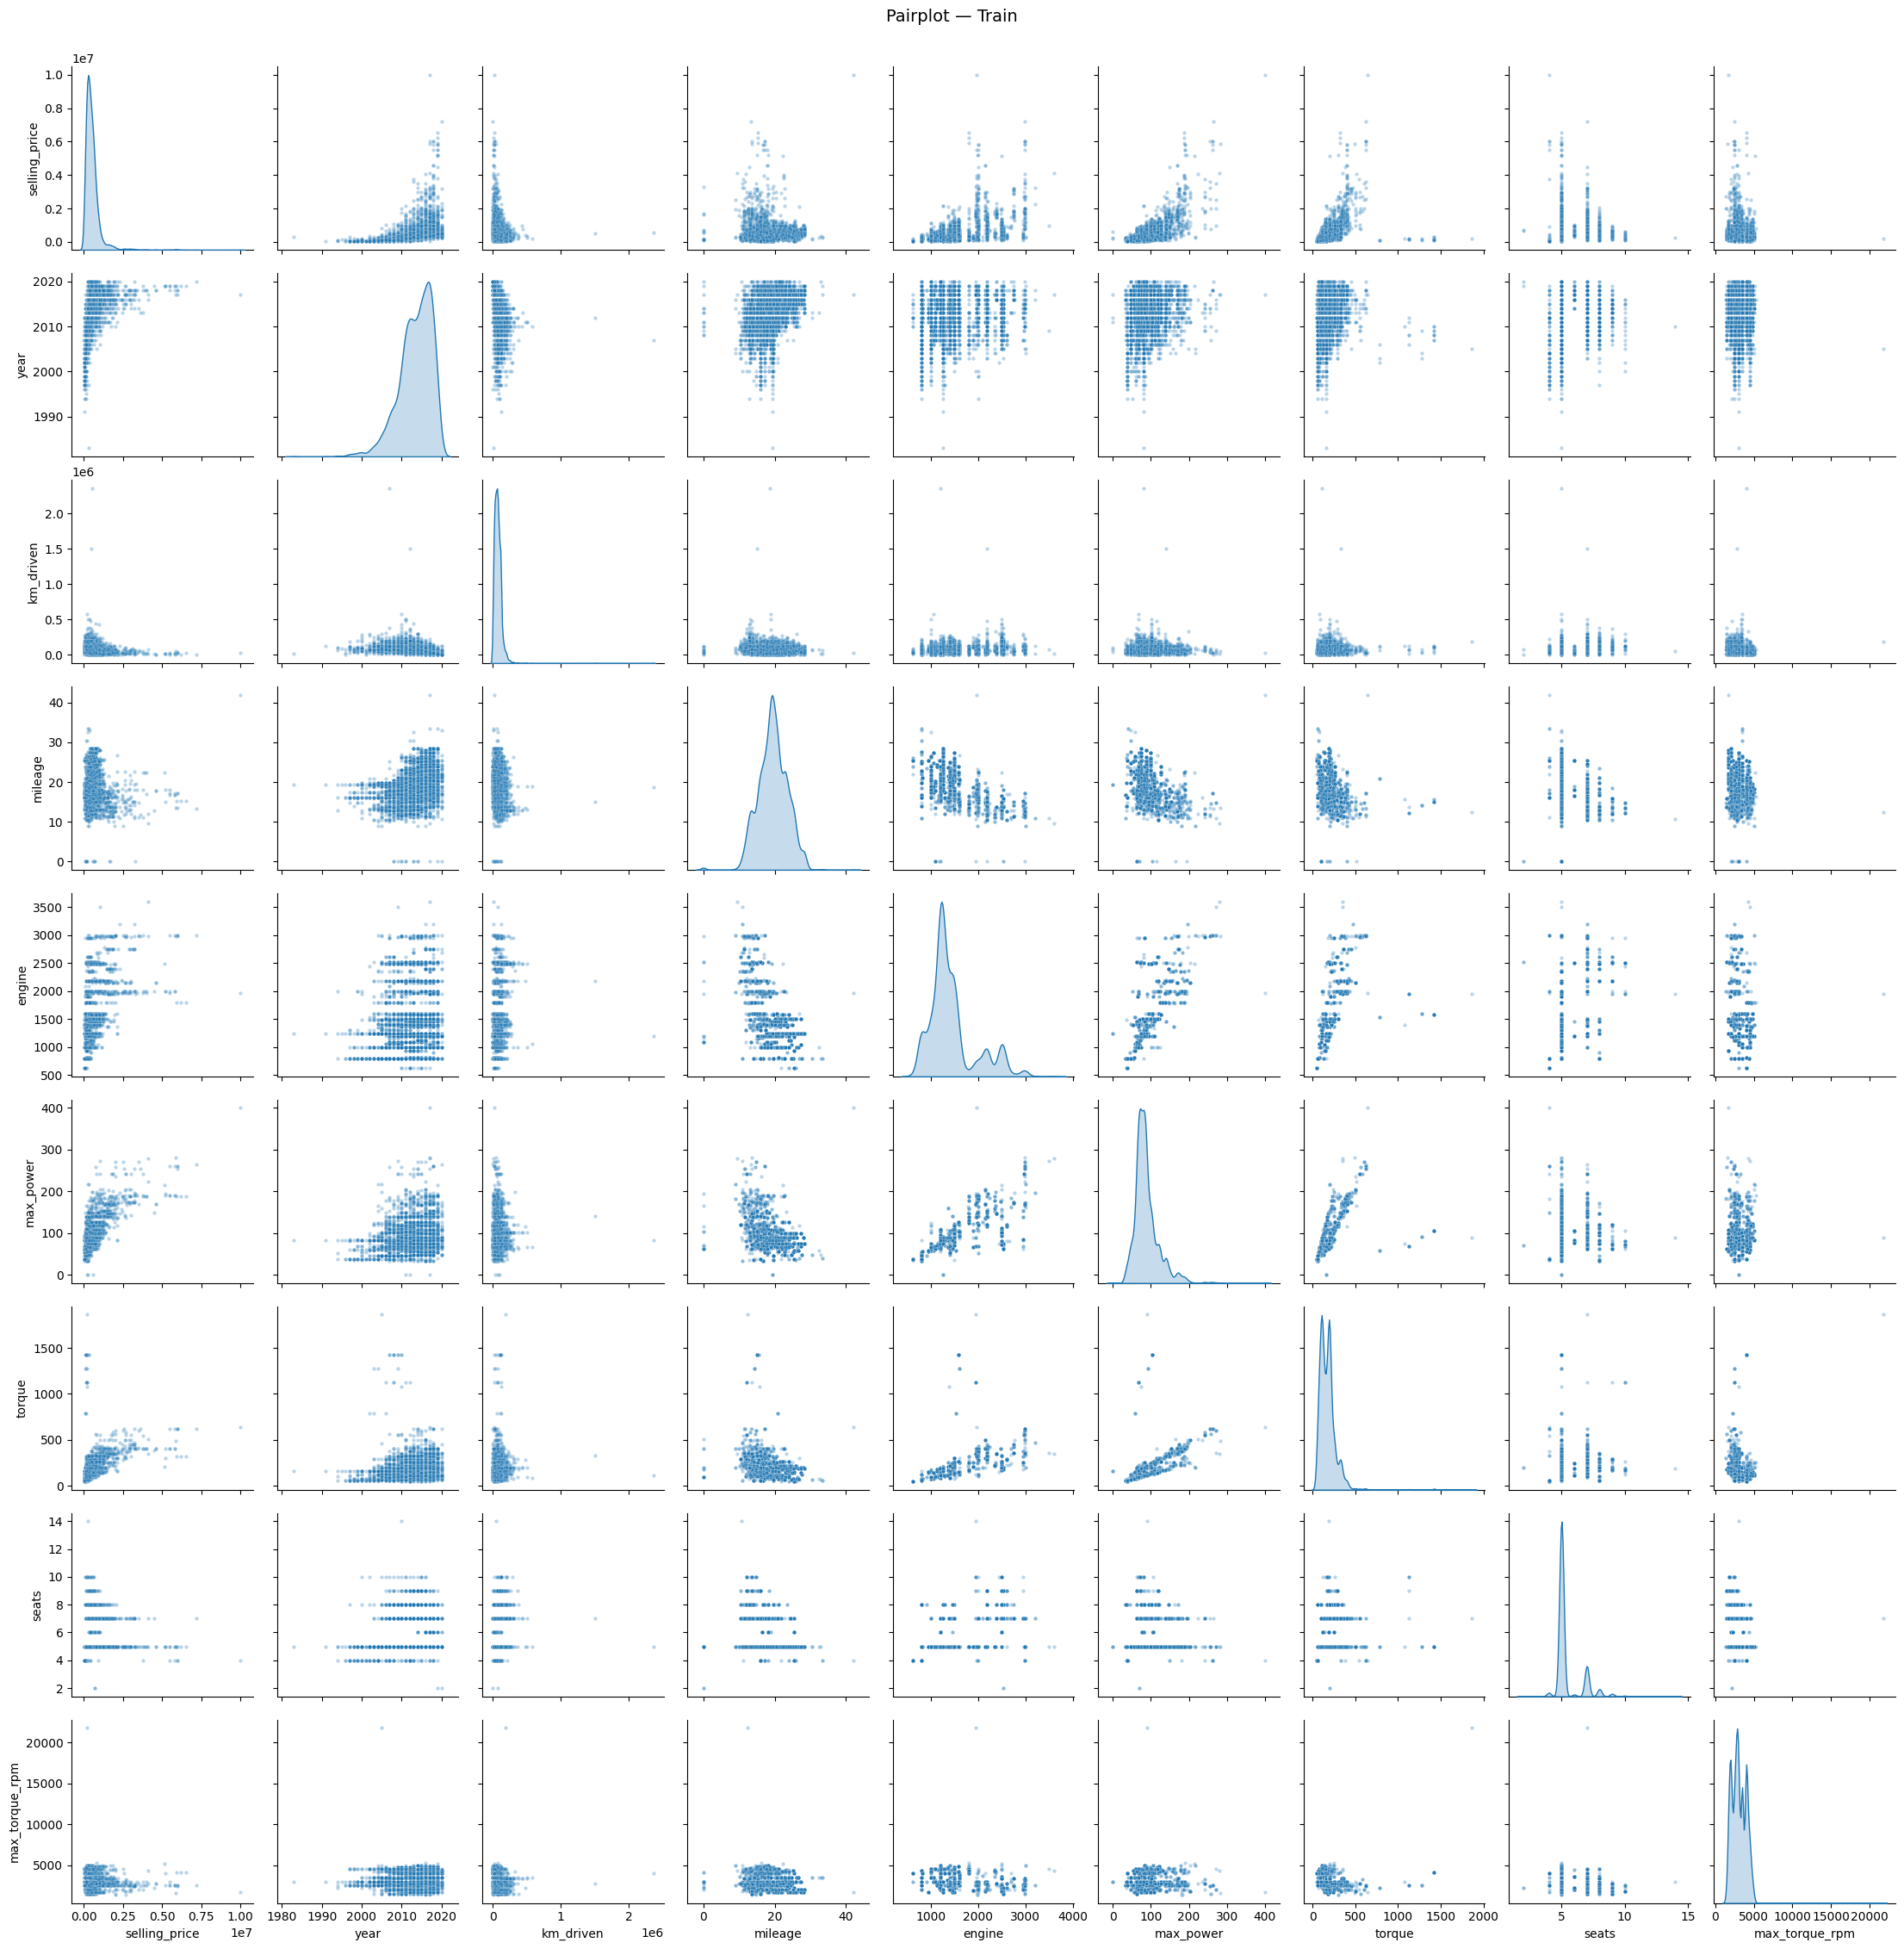

In [132]:
%matplotlib inline
# 1. Pairplot для train 

num_cols_with_target = ["selling_price", "year", "km_driven", 
                         "mileage", "engine", "max_power", 
                         "torque", "seats", "max_torque_rpm"]

g1 = sns.pairplot(
    df_train[num_cols_with_target],
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 10},
    diag_kws={"fill": True}
)
g1.figure.suptitle("Pairplot — Train", y=1.01, fontsize=14)
plt.close("all")  # закрываем лишние фигуры
display(g1.figure) # показываем только одну


Связь с целевой переменной selling_price:
Видны очень хорошие связи со следующими признаками: year (чем новее, тем дороже -- exp зависимость), engine (видна линейно растущая зависимость, но с большим разбросом данных), max_power (линейно растущая зависимость), torque (тоже линейная растущая зависимость), km_driven (тут тоже видна зависимость, похожа на логарифмическую).

Корреляция признаков:
engine -- torque;
engine -- max_power;
torque -- max_power.
У этих признаков точки лежат почти на одной линии

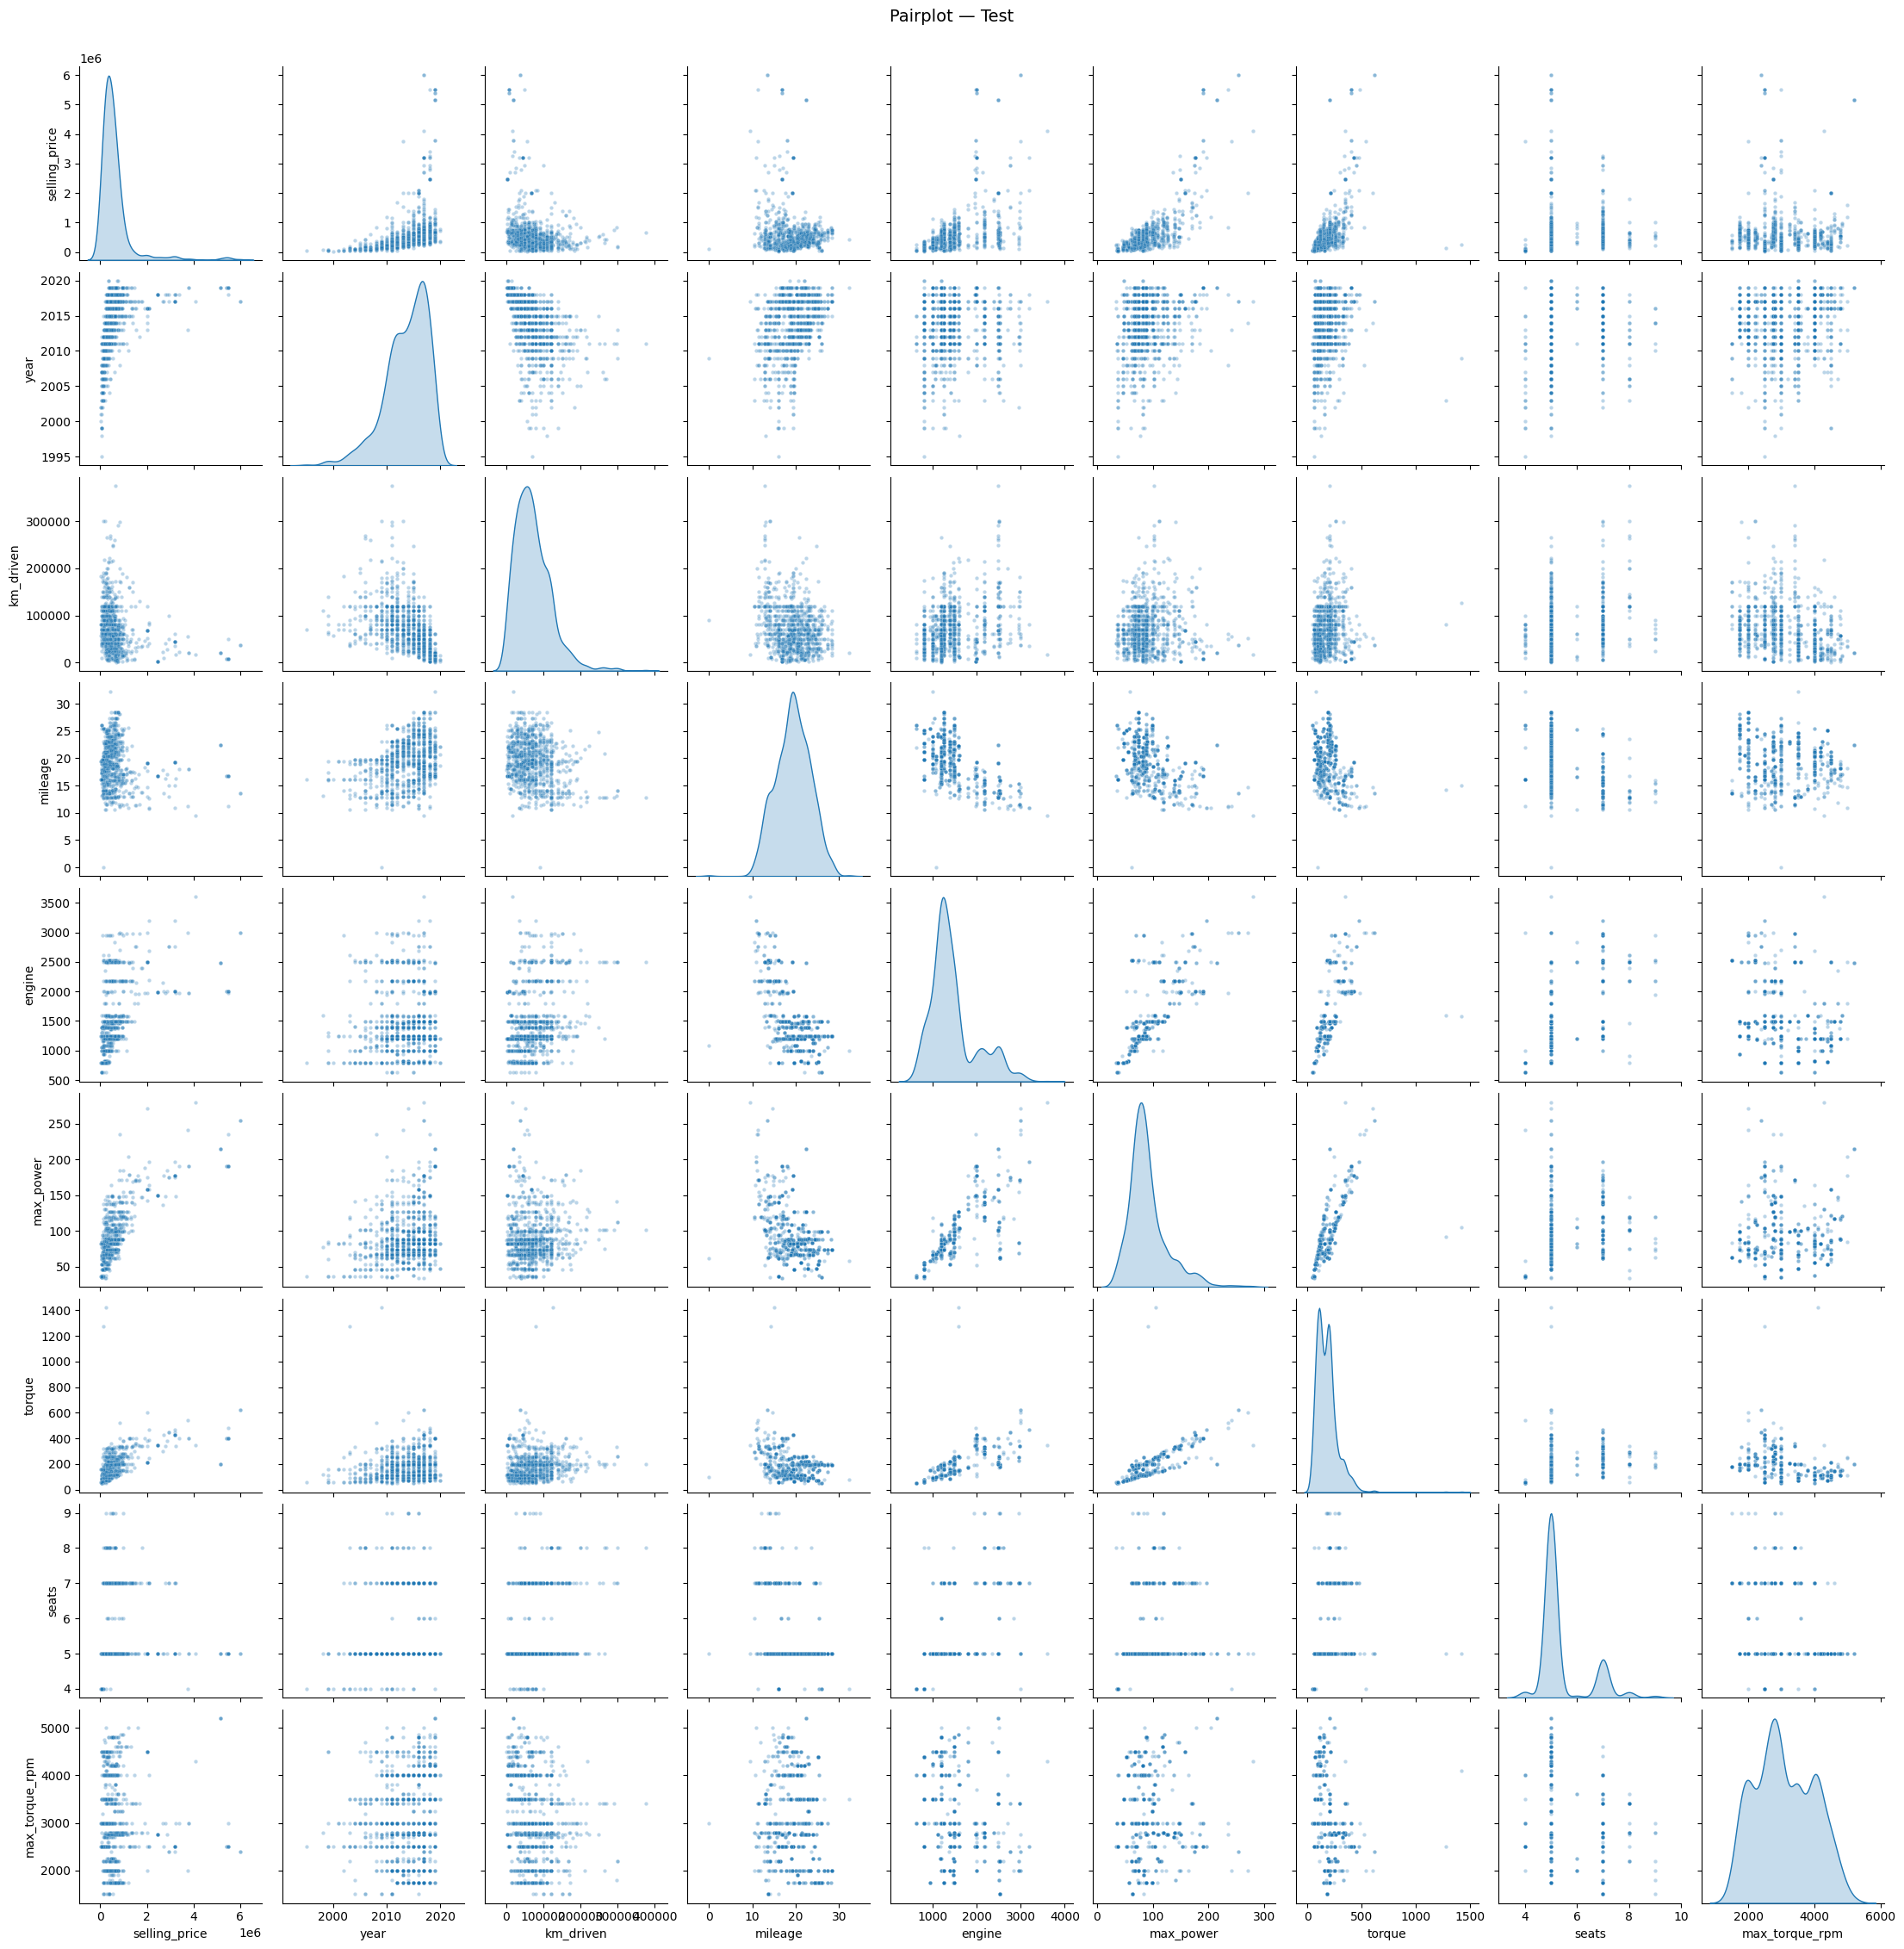

In [133]:
# 2. Pairplot для test 

test_cols = [col for col in num_cols_with_target if col in df_test.columns]

g2 = sns.pairplot(
    df_test[test_cols],
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 10},
    diag_kws={"fill": True}
)
g2.figure.suptitle("Pairplot — Test", y=1.01, fontsize=14)
plt.close("all")
display(g2.figure)

Графики распределений на диагонали на train и test похожи между собой, значит выборки однородны.

### **Задание 9 (1.5 балла)**

Итак, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

Корреляции с selling_price (по убыванию):
selling_price     1.000
max_power         0.693
torque            0.466
engine            0.448
year              0.427
seats             0.150
max_torque_rpm   -0.088
mileage          -0.105
km_driven        -0.165
Name: selling_price, dtype: float64


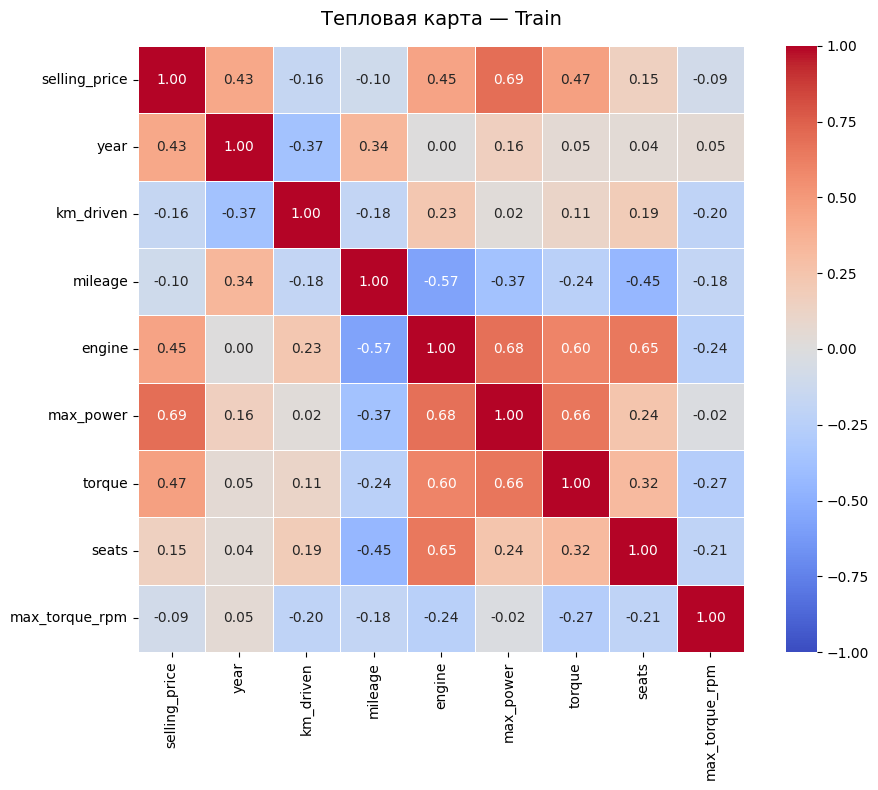

In [134]:
# 1. Матрица корреляций Пирсона

corr_matrix = df_train[num_cols_with_target].corr(method="pearson")

print("Корреляции с selling_price (по убыванию):")
print(corr_matrix["selling_price"].sort_values(ascending=False).round(3))


# 2. Тепловая карта

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,        
    fmt=".2f",           
    cmap="coolwarm",   
    center=0,           
    vmin=-1, vmax=1,
    square=True,       
    linewidths=0.5,
    ax=ax
)

ax.set_title("Тепловая карта — Train", fontsize=14, pad=15)
plt.tight_layout()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

1. max_power -- max_torque_rpm и engine -- year  (корреляция около 0 у обеих пар)
2. max_power --engine (0.68); torque -- max_power (0.66);  seats -- engine (0.65)
3. да, так можно утверждать, т.к. корреляция year -- km_driven = -0.37, что является умеренной отрицательной зависимостью.

### **Задание 10 (1.8 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией


Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


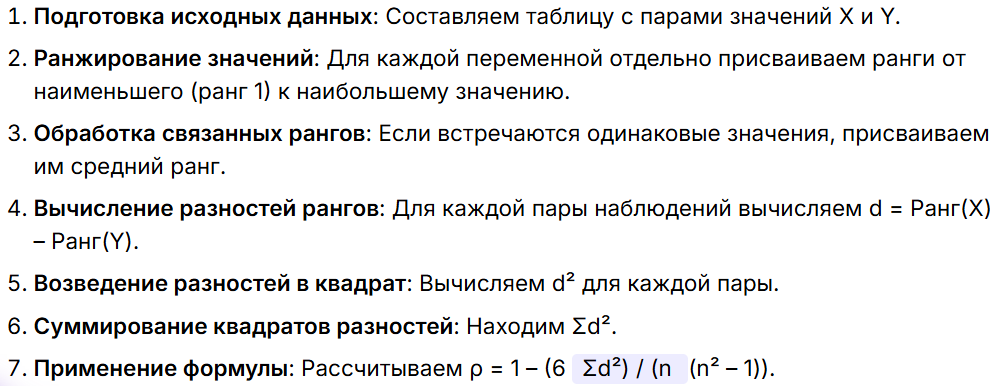

Максимальное расхождение с расчетом через библиотеку: 1.66e-01


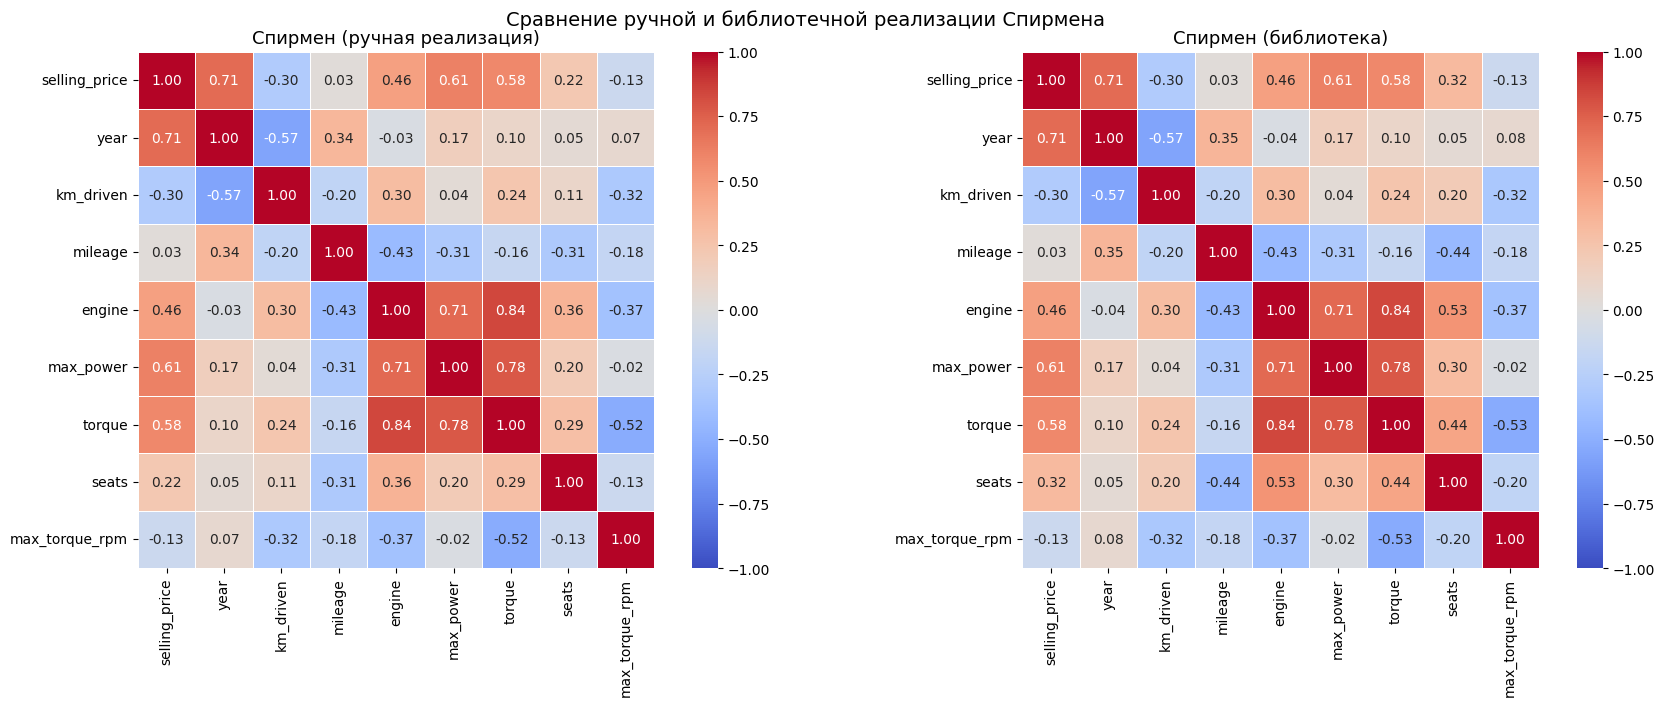

In [135]:
# 1. Корреляция Спирмена (прикрепил скрин алгоритма)

def spearman_corr_manual(x, y):
    def rank_array(arr):             
        return np.argsort(np.argsort(arr)).astype(float) + 1

    rank_x = rank_array(x)
    rank_y = rank_array(y)

    # Пирсон по рангам
    n = len(rank_x)
    mean_rx = rank_x.mean()
    mean_ry = rank_y.mean()

    numerator   = np.sum((rank_x - mean_rx) * (rank_y - mean_ry))
    denominator = np.sqrt(
        np.sum((rank_x - mean_rx) ** 2) * np.sum((rank_y - mean_ry) ** 2)
    )

    return numerator / denominator


# Корреляция Спирмена вручную для всех пар 

data_num = df_train[num_cols_with_target].dropna()
cols = data_num.columns

manual_spearman = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        manual_spearman.loc[col1, col2] = spearman_corr_manual(
            data_num[col1].values,
            data_num[col2].values   )

# расчет через библиотеку

lib_spearman = data_num.corr(method="spearman")

# Расхождения

diff = (manual_spearman - lib_spearman).abs()
print(f"Максимальное расхождение с расчетом через библиотеку: {diff.max().max():.2e}")

# Визуализация 

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, matrix, title in zip(
    axes,
    [manual_spearman, lib_spearman],
    ["Спирмен (ручная реализация)", "Спирмен (библиотека)"]
):
    sns.heatmap(
        matrix.astype(float),
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax
    )
    ax.set_title(title, fontsize=13)

plt.suptitle("Сравнение ручной и библиотечной реализации Спирмена", fontsize=14)
plt.tight_layout()



interval columns not set, guessing: ['selling_price', 'year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']


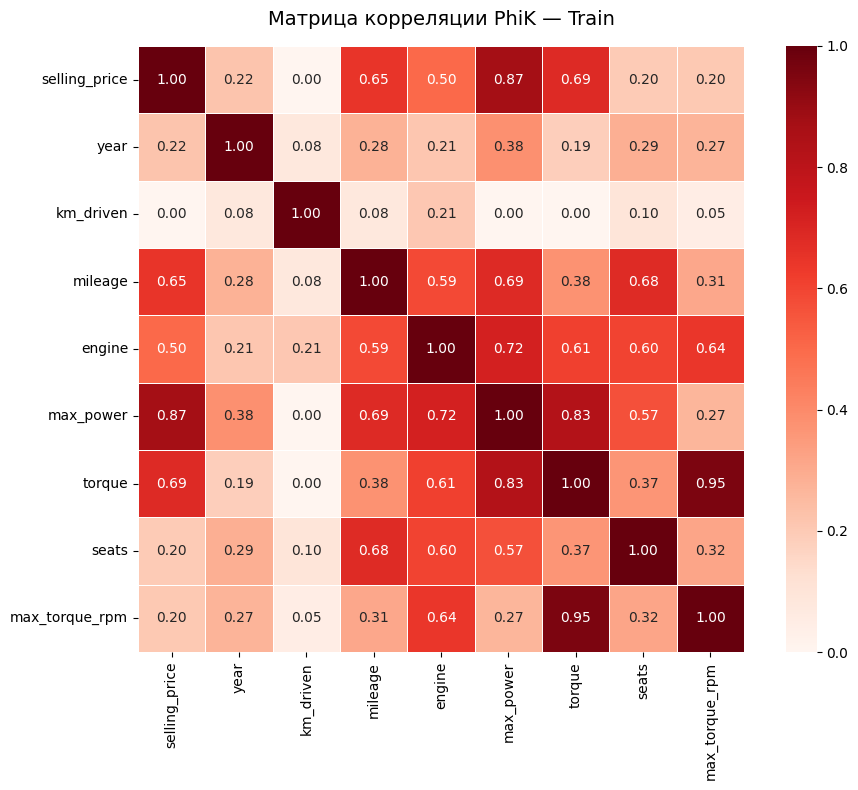

In [136]:
import phik

phik_matrix = df_train[num_cols_with_target].phik_matrix()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    phik_matrix,
    annot=True, fmt=".2f",
    cmap="Reds",       
    vmin=0, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title("Матрица корреляции PhiK — Train", fontsize=14, pad=15)
plt.tight_layout()

1. selling_price - mileage — Пирсон даёт −0.10 (почти нет связи), а PhiK — 0.65 (сильная). Это означает связь нелинейная.
2. torque - max_torque_rpm — PhiK 0.95 при Спирмене −0.52. Связь есть и очень сильная, но она нелинейная.
3. km_driven — PhiK 0.00 с ценой, хотя Пирсон и Спирмен показывают отрицательную связь. Это говорит о том, что связь линейная, но очень зашумлённая выбросами.
4. Для модели — PhiK показывает, что mileage и max_power несут больше информации о цене. Может быть такое, что лЛинейная модель это не уловит — стоит попробовать градиентный бустинг или случайный лес.

### **Дополнительные визуализации (0.3 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.

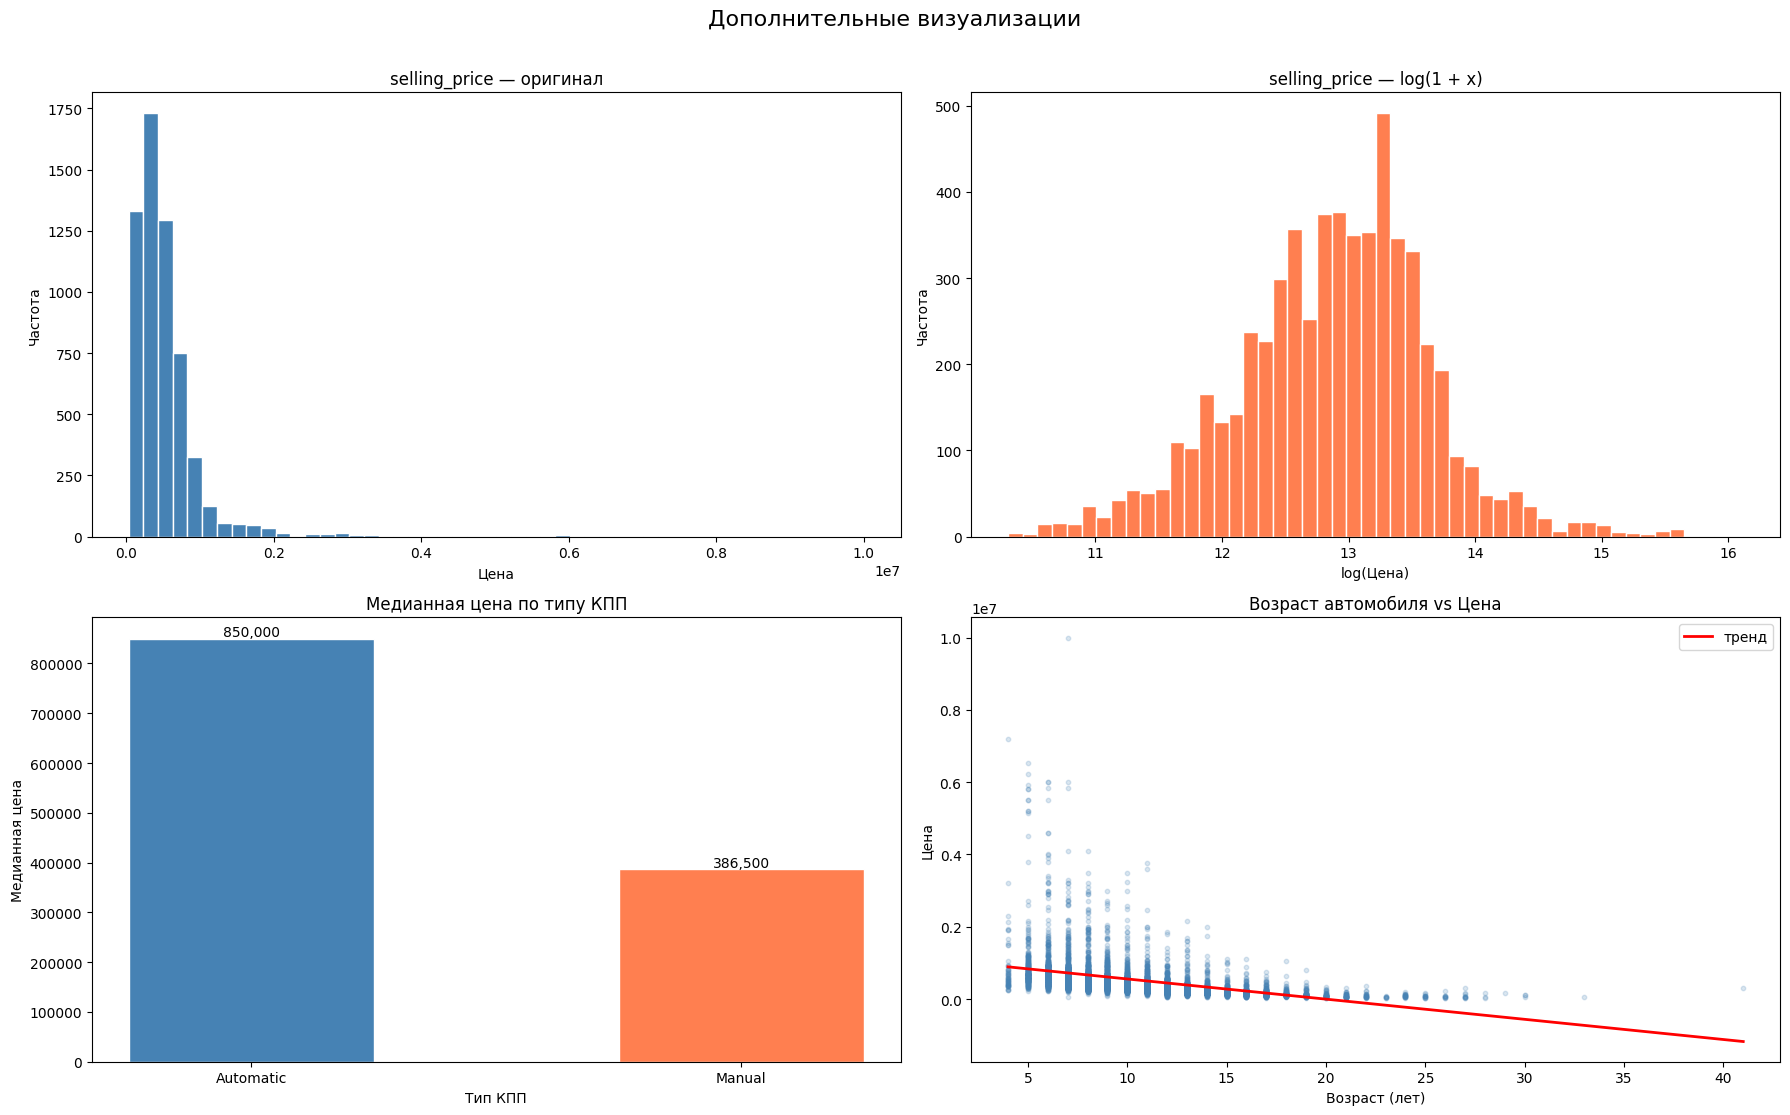

In [137]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle("Дополнительные визуализации", fontsize=16, y=1.01)


# ── 1. Распределение целевой переменной (оригинал vs log) ────────────────────

axes[0, 0].hist(df_train["selling_price"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("selling_price — оригинал")
axes[0, 0].set_xlabel("Цена")
axes[0, 0].set_ylabel("Частота")

axes[0, 1].hist(np.log1p(df_train["selling_price"]), bins=50, color="coral", edgecolor="white")
axes[0, 1].set_title("selling_price — log(1 + x)")
axes[0, 1].set_xlabel("log(Цена)")
axes[0, 1].set_ylabel("Частота")



# 3. Цена по типу КПП

transmission_stats = (df_train.groupby("transmission")["selling_price"]
                      .median()
                      .sort_values(ascending=False))

axes[1, 0].bar(
    transmission_stats.index,
    transmission_stats.values,
    color=["steelblue", "coral"],
    edgecolor="white",
    width=0.5
)
axes[1, 0].set_title("Медианная цена по типу КПП")
axes[1, 0].set_xlabel("Тип КПП")
axes[1, 0].set_ylabel("Медианная цена")

# Подписи значений над столбцами
for i, (name, val) in enumerate(transmission_stats.items()):
    axes[1, 0].text(i, val + 5000, f"{val:,.0f}", ha="center", fontsize=10)



# 4. Возраст автомобиля vs цена (scatter + тренд) 

df_train["car_age"] = 2024 - df_train["year"]

axes[1, 1].scatter(
    df_train["car_age"], df_train["selling_price"],
    alpha=0.2, s=10, color="steelblue"
)
# Линия тренда
z = np.polyfit(df_train["car_age"], df_train["selling_price"], 1)
p = np.poly1d(z)
x_line = np.linspace(df_train["car_age"].min(), df_train["car_age"].max(), 100)
axes[1, 1].plot(x_line, p(x_line), color="red", linewidth=2, label="тренд")
axes[1, 1].set_title("Возраст автомобиля vs Цена")
axes[1, 1].set_xlabel("Возраст (лет)")
axes[1, 1].set_ylabel("Цена")
axes[1, 1].legend()

plt.tight_layout()

1. selling_price — оригинал

Распределение сильно скошено вправо — подавляющее большинство автомобилей стоит до 2–3 млн, но есть длинный хвост до 10 млн. В целом это довольно типично для рынка авто: масс-маркет доминирует, премиум встречается редко. Но такое распределение может быть плохо для линейной регрессии — модель будет стремиться к выбросам.

2. selling_price — log(1 + x)

После логарифмирования распределение стало близким к нормальному с центром около 13. 

3. Медианная цена по типу КПП

Автомат (850 000) дороже механики (386 500) более чем в 2 раза. Transmission наверняка войдёт в топ важных признаков модели.

4. Возраст автомобиля vs Цена

У молодых авто (2–5 лет) разброс цен огромный (от 100к до 10 млн). Также видно, что авто старше 20 лет стоят стабильно дёшево и кучкуются у нуля.

In [ ]:
df_train.to_csv('chek.csv', encoding='utf-8')

# **Часть 2 (4.95+0.45 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.15 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [138]:
y_train = df_train["selling_price"]
X_train = df_train.drop(columns=cat_cols + ["selling_price", "car_age"])

In [139]:
X_train.shape

(5840, 8)

In [140]:
assert X_train.shape == (5840, 8)

In [141]:
y_test = df_test["selling_price"]
X_test = df_test.drop(columns=cat_cols + ["selling_price"])

In [142]:
X_test.shape

(1000, 8)

In [143]:
assert X_test.shape == (1000, 8)

### **Задание 12. (0.6 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred  = lr.predict(X_test)

def print_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test):
    print(f"{'Метрика':<10} {'Train':>15} {'Test':>15}")
    print("-" * 42)
    print(f"{'R²':<10} {r2_score(y_true_train, y_pred_train):>15.4f} "
          f"{r2_score(y_true_test, y_pred_test):>15.4f}")
    print(f"{'MSE':<10} {MSE(y_true_train, y_pred_train):>15.0f} "
          f"{MSE(y_true_test, y_pred_test):>15.0f}")
    print(f"{'RMSE':<10} {np.sqrt(MSE(y_true_train, y_pred_train)):>15.0f} "
          f"{np.sqrt(MSE(y_true_test, y_pred_test)):>15.0f}")


print_metrics(y_train, y_train_pred, y_test, y_test_pred)

Метрика              Train            Test
------------------------------------------
R²                  0.6011          0.6004
MSE           114330897499    229701013986
RMSE                338129          479271


Переобучения нет -- R² на train и test почти одинаковые 
RMSE на train и test сильно отличаются, но это может говорить о том, что на тесте дорогих авто больше (RMSE показывает реальные условные единицы, в нашем случае -- это цена)

### **Задание 13 (0.45 балла)**

- [ ] Реализуйте $R^2$ руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

In [ ]:
def r2(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # SS_res — сумма квадратов остатков 
    ss_res = np.sum((y_true - y_pred) ** 2)

    # SS_tot — полная сумма квадратов 
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)

    return 1 - ss_res / ss_tot


# Проверка с библиотекой

r2_train_manual = r2(y_train, y_train_pred)
r2_test_manual  = r2(y_test,  y_test_pred)

r2_train_lib    = r2_score(y_train, y_train_pred)
r2_test_lib     = r2_score(y_test,  y_test_pred)

print(f"{'':10} {'Train':>10} {'Test':>10}")
print(f"{'Ручной':10} {r2_train_manual:>10.4f} {r2_test_manual:>10.4f}")
print(f"{'Sklearn':10} {r2_train_lib:>10.4f} {r2_test_lib:>10.4f}")
print(f"{'Разница':10} {abs(r2_train_manual-r2_train_lib):>10.2e} "
      f"{abs(r2_test_manual-r2_test_lib):>10.2e}")

                Train       Test
Ручной         0.6011     0.6004
Sklearn        0.6011     0.6004
Разница      0.00e+00   0.00e+00


Формула R^2:

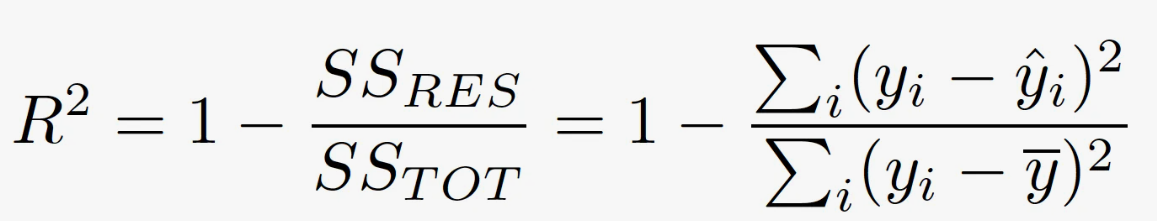

Сумма квадратов остатков — суммарная ошибка модели. Чем лучше предсказывает модель, тем меньше это число.

Полная сумма квадратов — дисперсия целевой переменной.

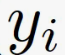 -- таргет

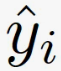 -- предсказание модели

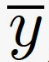 -- среднее значение зависимой переменной.

### **Бонус (0.45 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [150]:
def adjusted_r2(y_true, y_pred, X):
    n = X.shape[0]
    p = X.shape[1]

    r2_ = r2(y_true, y_pred)

    return 1 - (1 - r2_) * (n - 1) / (n - p - 1)


# Проверка 

adj_r2_train = adjusted_r2(y_train, y_train_pred, X_train)
adj_r2_test  = adjusted_r2(y_test,  y_test_pred,  X_test)

print(f"{'':15} {'Train':>10} {'Test':>10}")
print("-" * 37)
print(f"{'R²':15} {r2_train_manual:>10.4f} {r2_test_manual:>10.4f}")
print(f"{'Adjusted R²':15} {adj_r2_train:>10.4f} {adj_r2_test:>10.4f}")
print(f"{'Разница':15} {abs(r2_train_manual - adj_r2_train):>10.4f} "
      f"{abs(r2_test_manual - adj_r2_test):>10.4f}")

                     Train       Test
-------------------------------------
R²                  0.6011     0.6004
Adjusted R²         0.6006     0.5972
Разница             0.0005     0.0032


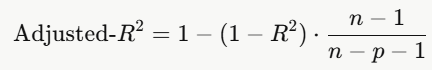

Это улучшенная версия R^2, которая учитывает кол-во признаков в модели. 
Adjusted - R^2 штрафует за каждый новый признак через коэффициент у (1-R^2)​. Если признак не несёт информации — Adjusted - R^2 снизится.  
Хорошая метрика при отборе признаков -- добавить признак, когда Adjusted - R^2 растет

### **Задание 14 (0.45 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

Как изменилось качество модели?

In [152]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit + transform на train
X_test_scaled  = scaler.transform(X_test)        # только transform на test

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

y_train_pred_scaled = lr_scaled.predict(X_train_scaled)
y_test_pred_scaled  = lr_scaled.predict(X_test_scaled)

print(f"{'':20} {'Train':>10} {'Test':>10}")
print("До стандартизации:")
print(f"  {'R²':18} {r2_score(y_train, y_train_pred):>10.4f} "
      f"{r2_score(y_test, y_test_pred):>10.4f}")
print(f"  {'RMSE':18} {np.sqrt(MSE(y_train, y_train_pred)):>10.0f} "
      f"{np.sqrt(MSE(y_test, y_test_pred)):>10.0f}")
print("После стандартизации:")
print(f"  {'R²':18} {r2_score(y_train, y_train_pred_scaled):>10.4f} "
      f"{r2_score(y_test, y_test_pred_scaled):>10.4f}")
print(f"  {'RMSE':18} {np.sqrt(MSE(y_train, y_train_pred_scaled)):>10.0f} "
      f"{np.sqrt(MSE(y_test, y_test_pred_scaled)):>10.0f}")

                          Train       Test
До стандартизации:
  R²                     0.6011     0.6004
  RMSE                   338129     479271
После стандартизации:
  R²                     0.6011     0.6004
  RMSE                   338129     479271


Метрики не изменились

### **Задание 15 (0.3 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве, она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

       feature   coefficient      abs_coef
     max_power 328812.594830 328812.594830
          year 165653.919200 165653.919200
max_torque_rpm -58861.193842  58861.193842
     km_driven -48954.378341  48954.378341
         seats -30409.458978  30409.458978
        engine  22317.932021  22317.932021
       mileage  -8488.329038   8488.329038
        torque   7887.816316   7887.816316


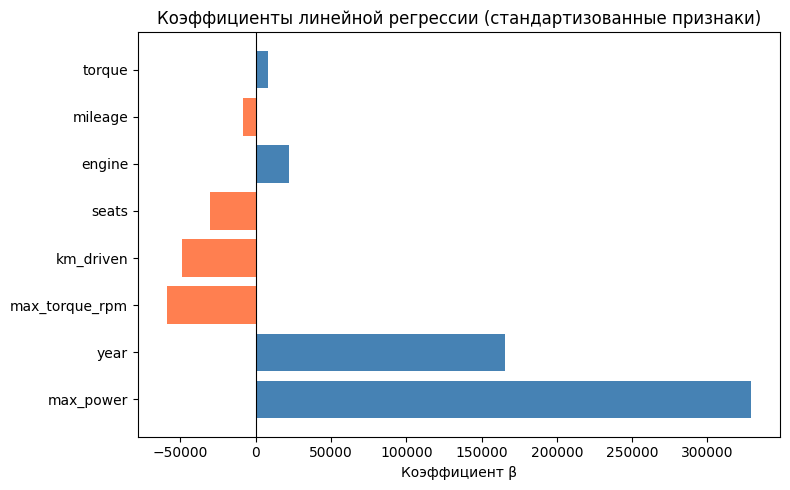

In [153]:
coef_df = pd.DataFrame({
    "feature":     X_train.columns,
    "coefficient": lr_scaled.coef_
}).assign(abs_coef=lambda x: x["coefficient"].abs()).sort_values("abs_coef", ascending=False)

print(coef_df.to_string(index=False))


fig, ax = plt.subplots(figsize=(8, 5))

colors = ["steelblue" if c > 0 else "coral" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Коэффициенты линейной регрессии (стандартизованные признаки)")
ax.set_xlabel("Коэффициент β")
plt.tight_layout()

Самый информативный признак -- max_power, что соответствует корреляционному анализу

### **Задание 16 (0.75 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

                          Train       Test
Линейная регрессия:
  R²                     0.6011     0.6004
  RMSE                   338129     479271
Lasso:
  R²                     0.6011     0.6004
  RMSE                   338129     479272

Коэффициенты Lasso:
       feature   coefficient
     max_power 328813.997752
          year 165651.722595
max_torque_rpm -58859.113102
     km_driven -48953.434528
         seats -30405.476356
        engine  22315.925938
       mileage  -8485.045858
        torque   7887.175681

Кол-во зануленных признаков: 0


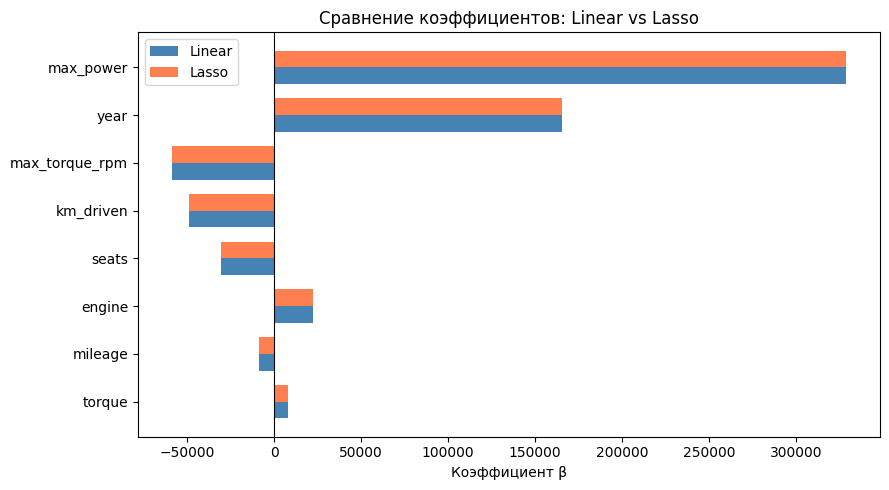

In [157]:
from sklearn.linear_model import Lasso

lasso = Lasso(random_state=RANDOM_STATE)  # берём alpha=1.0 по умолчанию
lasso.fit(X_train_scaled, y_train)

y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso  = lasso.predict(X_test_scaled)

print(f"{'':20} {'Train':>10} {'Test':>10}")
print("Линейная регрессия:")
print(f"  {'R²':18} {r2_score(y_train, y_train_pred_scaled):>10.4f} "
      f"{r2_score(y_test, y_test_pred_scaled):>10.4f}")
print(f"  {'RMSE':18} {np.sqrt(MSE(y_train, y_train_pred_scaled)):>10.0f} "
      f"{np.sqrt(MSE(y_test, y_test_pred_scaled)):>10.0f}")
print("Lasso:")
print(f"  {'R²':18} {r2_score(y_train, y_train_pred_lasso):>10.4f} "
      f"{r2_score(y_test, y_test_pred_lasso):>10.4f}")
print(f"  {'RMSE':18} {np.sqrt(MSE(y_train, y_train_pred_lasso)):>10.0f} "
      f"{np.sqrt(MSE(y_test, y_test_pred_lasso)):>10.0f}")


# Проверка на зануления коэффициентов 

coef_lasso = pd.DataFrame({
    "feature":     X_train.columns,
    "coefficient": lasso.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nКоэффициенты Lasso:")
print(coef_lasso.to_string(index=False))

zeroed = coef_lasso[coef_lasso["coefficient"] == 0]
print(f"\nКол-во зануленных признаков: {len(zeroed)}")


# Визуализация 

coef_compare = pd.DataFrame({
    "feature":    X_train.columns,
    "LinearReg":  lr_scaled.coef_,
    "Lasso":      lasso.coef_
}).set_index("feature").sort_values("LinearReg", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(coef_compare))
width = 0.35

ax.barh(x - width/2, coef_compare["LinearReg"], width, label="Linear", color="steelblue")
ax.barh(x + width/2, coef_compare["Lasso"],     width, label="Lasso",  color="coral")
ax.set_yticks(x)
ax.set_yticklabels(coef_compare.index)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Сравнение коэффициентов: Linear vs Lasso")
ax.set_xlabel("Коэффициент β")
ax.legend()
plt.tight_layout()

1. Метрики идентичны — R² и RMSE у Lasso и Linear совпадают. Это значит, что alpha=1.0 слишком мал для данных с масштабом коэффициентов в сотни тысяч.

2. Зануленных признаков -- 0ю 

3. На графике видно, что синие и оранжевые столбцы совпадают — Lasso почти не изменил коэффициенты по сравнению с обычной линейной регрессией.

Нужно попробовать другой коэф для Lasso, чтобы пр-ки занулились, например можно это сделать через кросс-валидацию

### **Задание 17. Финальный рывок (1.2 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Лучший alpha:   10000
Лучший R² (CV): 0.5805

                          Train       Test
  R²                     0.5984     0.5868
  RMSE                   339299     487355

Коэффициенты лучшей модели:
       feature   coefficient
     max_power 335071.769039
          year 153811.054182
max_torque_rpm -45278.215117
     km_driven -39206.645166
        torque   2895.542941
         seats   -559.362208
       mileage      0.000000
        engine      0.000000

Зануленных признаков: 2
Зануленные: ['mileage', 'engine']


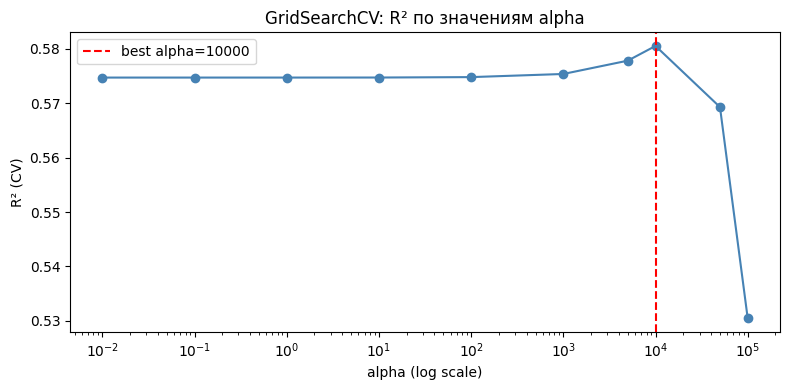

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000, 5000, 10000, 50000, 100000],}

lasso_gs = GridSearchCV(
    estimator=Lasso(random_state=RANDOM_STATE, max_iter=10000),  # это модель у которой мы перебираем параметры
    param_grid=param_grid,      # словарь, в котором указаны параметры для перебора (в нашем случае это alpha) 
    cv=10,          # кол-во фолдов кросс-валидации
    scoring="r2",   # метрика для выбора лучшей модели
    n_jobs=-1,      # указываем кол-во параллельных потоков, -1 означает исп все ядра процессора
    verbose=1       # уровень логирования (1 - общий прогресс)
)

lasso_gs.fit(X_train_scaled, y_train)


print(f"Лучший alpha:   {lasso_gs.best_params_['alpha']}")
print(f"Лучший R² (CV): {lasso_gs.best_score_:.4f}")

best_lasso = lasso_gs.best_estimator_

y_train_pred_best = best_lasso.predict(X_train_scaled)
y_test_pred_best  = best_lasso.predict(X_test_scaled)

print(f"\n{'':20} {'Train':>10} {'Test':>10}")
print(f"  {'R²':18} {r2_score(y_train, y_train_pred_best):>10.4f} "
      f"{r2_score(y_test, y_test_pred_best):>10.4f}")
print(f"  {'RMSE':18} {np.sqrt(MSE(y_train, y_train_pred_best)):>10.0f} "
      f"{np.sqrt(MSE(y_test, y_test_pred_best)):>10.0f}")



coef_best = pd.DataFrame({
    "feature":     X_train.columns,
    "coefficient": best_lasso.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nКоэффициенты лучшей модели:")
print(coef_best.to_string(index=False))

zeroed = coef_best[coef_best["coefficient"] == 0]
print(f"\nЗануленных признаков: {len(zeroed)}")
if len(zeroed) > 0:
    print(f"Зануленные: {zeroed['feature'].tolist()}")



results = pd.DataFrame(lasso_gs.cv_results_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(results["param_alpha"], results["mean_test_score"],
            marker="o", color="steelblue")
ax.axvline(lasso_gs.best_params_["alpha"], color="red",
           linestyle="--", label=f"best alpha={lasso_gs.best_params_['alpha']}")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("R² (CV)")
ax.set_title("GridSearchCV: R² по значениям alpha")
ax.legend()
plt.tight_layout()

GridSearchCV обучил 100 моделей.

Занулились 2 пр-ка при alpha = 10000 : mileage и engine

**Ваша задача 2:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

Fitting 10 folds for each of 60 candidates, totalling 600 fits
Лучшие параметры: {'alpha': 1, 'l1_ratio': 0.9}
Лучший R² (CV):   0.5811

                          Train       Test
  R²                     0.5956     0.5774
  RMSE                   340461     492847

Коэффициенты лучшей ElasticNet:
       feature   coefficient
     max_power 269977.679088
          year 153947.882795
        engine  52366.712546
     km_driven -51053.817266
max_torque_rpm -40700.937287
        torque  33487.873830
         seats -32523.439056
       mileage  -1100.073105

Зануленных признаков: 0


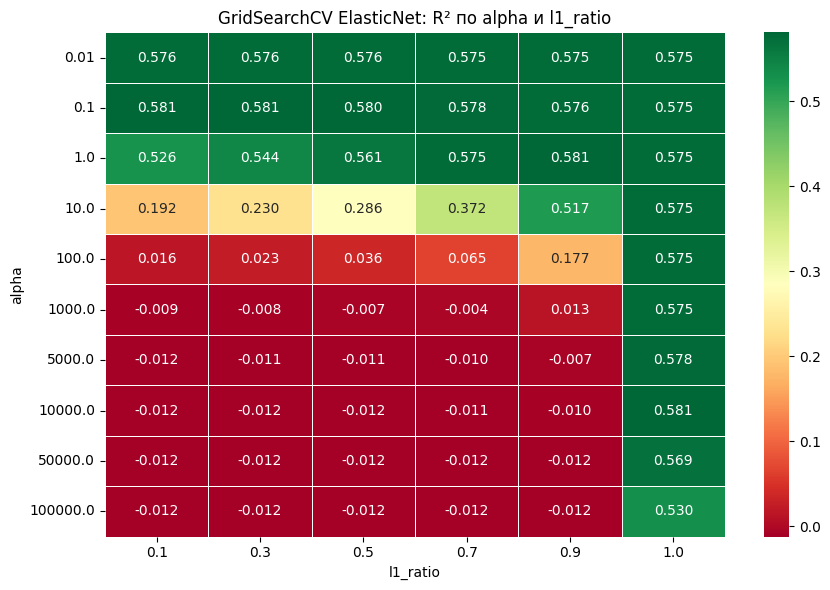

In [ ]:
from sklearn.linear_model import ElasticNet

param_grid_en = {
    "alpha":    [0.01, 0.1, 1, 10, 100, 1000, 5000, 10000, 50000, 100000],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

en_gs = GridSearchCV(
    estimator=ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    param_grid=param_grid_en,
    cv=10,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

en_gs.fit(X_train_scaled, y_train)


print(f"Лучшие параметры: {en_gs.best_params_}")
print(f"Лучший R² (CV):   {en_gs.best_score_:.4f}")

best_en = en_gs.best_estimator_

y_train_pred_en = best_en.predict(X_train_scaled)
y_test_pred_en  = best_en.predict(X_test_scaled)

print(f"\n{'':20} {'Train':>10} {'Test':>10}")
print(f"  {'R²':18} {r2_score(y_train, y_train_pred_en):>10.4f} "
      f"{r2_score(y_test, y_test_pred_en):>10.4f}")
print(f"  {'RMSE':18} {np.sqrt(MSE(y_train, y_train_pred_en)):>10.0f} "
      f"{np.sqrt(MSE(y_test, y_test_pred_en)):>10.0f}")


coef_en = pd.DataFrame({
    "feature":     X_train.columns,
    "coefficient": best_en.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nКоэффициенты лучшей ElasticNet:")
print(coef_en.to_string(index=False))

zeroed_en = coef_en[coef_en["coefficient"] == 0]
print(f"\nЗануленных признаков: {len(zeroed_en)}")
if len(zeroed_en) > 0:
    print(f"Зануленные: {zeroed_en['feature'].tolist()}")



# Тепловая карта R² по сетке параметров 

results_en = pd.DataFrame(en_gs.cv_results_)
pivot = results_en.pivot_table(
    index="param_alpha",
    columns="param_l1_ratio",
    values="mean_test_score"
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",
            ax=ax, linewidths=0.5)
ax.set_title("GridSearchCV ElasticNet: R² по alpha и l1_ratio")
ax.set_xlabel("l1_ratio")
ax.set_ylabel("alpha")
plt.tight_layout()

GridSearch обучил 600 моделей

Лучшие параметры: alpha=1, l1_ratio=0.9 => 0.581

### **Задание 18 (1.05 балла)**

Итак, вы обучили все варианты регуляризаций, доступные в sklearn, но есть и другие варианты! И следующее задание о забытой $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



L0-регуляризация: перебор подмножеств признаков
k= 1 | R²_train=0.4800 | R²_test=0.5128 | Признаки: ['max_power']
k= 2 | R²_train=0.5841 | R²_test=0.5813 | Признаки: ['year', 'max_power']
k= 3 | R²_train=0.5924 | R²_test=0.5834 | Признаки: ['year', 'max_power', 'max_torque_rpm']
k= 4 | R²_train=0.5996 | R²_test=0.5964 | Признаки: ['year', 'km_driven', 'max_power', 'max_torque_rpm']
k= 5 | R²_train=0.6003 | R²_test=0.5995 | Признаки: ['year', 'km_driven', 'max_power', 'seats', 'max_torque_rpm']
k= 6 | R²_train=0.6009 | R²_test=0.6004 | Признаки: ['year', 'km_driven', 'engine', 'max_power', 'seats', 'max_torque_rpm']
k= 7 | R²_train=0.6010 | R²_test=0.6002 | Признаки: ['year', 'km_driven', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']
k= 8 | R²_train=0.6011 | R²_test=0.6004 | Признаки: ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']

Лучшая модель:
  k = 8 признаков
  Признаки: ['year', 'km_driven', 'mileage', 'engine', 'max_powe

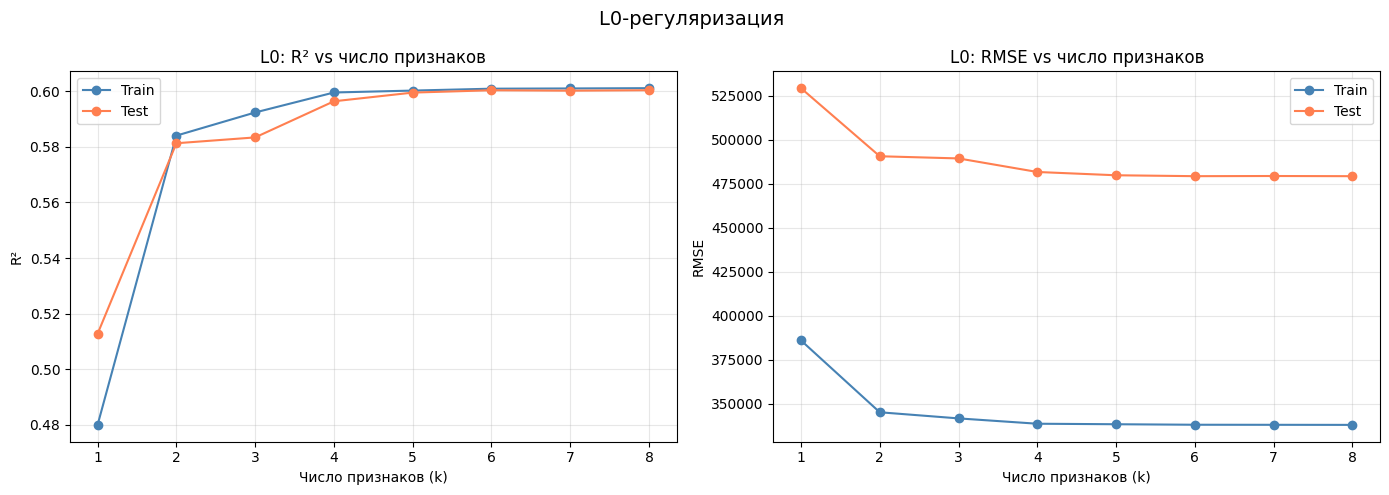

In [165]:
from itertools import combinations

def l0_regression(X_train, y_train, X_test, y_test, max_features=None):
  
    if max_features is None:
        max_features = X_train.shape[1]

    n_features = X_train.shape[1]
    feature_names = X_train.columns.tolist()
    results = []

    for k in range(1, max_features + 1):
        best_r2    = -np.inf
        best_combo = None
        best_model = None

        for combo in combinations(range(n_features), k):
            cols = list(combo)
            lr = LinearRegression()
            lr.fit(X_train.iloc[:, cols], y_train)
            r2 = r2_score(y_train, lr.predict(X_train.iloc[:, cols]))

            if r2 > best_r2:
                best_r2    = r2
                best_combo = cols
                best_model = lr

        y_pred_train = best_model.predict(X_train.iloc[:, best_combo])
        y_pred_test  = best_model.predict(X_test.iloc[:, best_combo])

        results.append({
            "k":          k,
            "features":   [feature_names[i] for i in best_combo],
            "r2_train":   r2_score(y_train, y_pred_train),
            "r2_test":    r2_score(y_test,  y_pred_test),
            "rmse_train": np.sqrt(MSE(y_train, y_pred_train)),
            "rmse_test":  np.sqrt(MSE(y_test,  y_pred_test)),
            "model":      best_model,
            "cols":       best_combo,
        })

        print(f"k={k:2d} | R²_train={best_r2:.4f} | "
              f"R²_test={results[-1]['r2_test']:.4f} | "
              f"Признаки: {results[-1]['features']}")

    return pd.DataFrame(results)


# Запуск 

print("L0-регуляризация: перебор подмножеств признаков")
results_l0 = l0_regression(X_train, y_train, X_test, y_test)


# Визуализация 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² в зависимости от числа признаков
axes[0].plot(results_l0["k"], results_l0["r2_train"],
             marker="o", label="Train", color="steelblue")
axes[0].plot(results_l0["k"], results_l0["r2_test"],
             marker="o", label="Test",  color="coral")
axes[0].set_xlabel("Число признаков (k)")
axes[0].set_ylabel("R²")
axes[0].set_title("L0: R² vs число признаков")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE в зависимости от числа признаков
axes[1].plot(results_l0["k"], results_l0["rmse_train"],
             marker="o", label="Train", color="steelblue")
axes[1].plot(results_l0["k"], results_l0["rmse_test"],
             marker="o", label="Test",  color="coral")
axes[1].set_xlabel("Число признаков (k)")
axes[1].set_ylabel("RMSE")
axes[1].set_title("L0: RMSE vs число признаков")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("L0-регуляризация ", fontsize=14)
plt.tight_layout()


# Лучшая модель 

best_row = results_l0.loc[results_l0["r2_test"].idxmax()]
print(f"\nЛучшая модель:")
print(f"  k = {best_row['k']} признаков")
print(f"  Признаки: {best_row['features']}")
print(f"  R²  train={best_row['r2_train']:.4f}  test={best_row['r2_test']:.4f}")
print(f"  RMSE train={best_row['rmse_train']:.0f}  test={best_row['rmse_test']:.0f}")

R² на test растёт резко до k=4, затем почти не меняется. То есть это локоть, после которой добавление признаков не дает прироста качества.

# **Часть 3 (1.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.5 основных балла.



### **Задание 19 (0.3 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

In [168]:
# Извлекаем марку из названия 

df_train["brand"] = df_train["name"].str.split().str[0]
df_test["brand"]  = df_test["name"].str.split().str[0]

print("Уникальных марок:", df_train["brand"].nunique())
print(df_train["brand"].value_counts().head(10))


# Берём числовые + категориальные (без name, оставляем brand)

cat_features = ["fuel", "seller_type", "transmission", "owner", "brand"]

X_train_cat = pd.concat([X_train, df_train[cat_features]], axis=1)
X_test_cat  = pd.concat([X_test,  df_test[cat_features]],  axis=1)

print(f"\nX_train_cat shape: {X_train_cat.shape}")
print(f"X_test_cat shape:  {X_test_cat.shape}")

Уникальных марок: 30
brand
Maruti        1804
Hyundai       1058
Mahindra       611
Tata           534
Toyota         309
Ford           308
Honda          308
Chevrolet      188
Renault        171
Volkswagen     153
Name: count, dtype: int64

X_train_cat shape: (5840, 13)
X_test_cat shape:  (1000, 13)


In [169]:
assert X_train_cat.shape == (5840, 13)

In [170]:
X_train_cat.describe(include='object')

,fuel,seller_type,transmission,owner,brand
count,5840,5840,5840,5840,5840
unique,4,3,2,5,30
top,Diesel,Individual,Manual,First Owner,Maruti
freq,3177,5223,5336,3603,1804


### **Задание 20 (0.3 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [ ]:
from sklearn.preprocessing import OneHotEncoder # или можно использовать get_dummies из библиотеки pandas

cat_features_ohe = ["fuel", "seller_type", "transmission",
                    "owner", "brand", "seats"]

X_train_ohe = pd.get_dummies(X_train_cat, columns=cat_features_ohe, drop_first=True)
X_test_ohe  = pd.get_dummies(X_test_cat,  columns=cat_features_ohe, drop_first=True)

# Выравниваем столбцы 
X_test_ohe = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

print(f"X_train_ohe shape: {X_train_ohe.shape}")
print(f"X_test_ohe shape:  {X_test_ohe.shape}")

X_train_ohe shape: (5840, 54)
X_test_ohe shape:  (1000, 54)


### **Задание 21 (0.6 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

1. fit только на train
2. Если признак имеет n категорий, OHE создаёт n столбцов. Но последний столбец линейно зависит от остальных — если все остальные равны 0, значит этот равен 1. Это мультиколлинеарность, которая ломает линейную регрессию.


### **Задание 22 (0.3 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [174]:
from sklearn.linear_model import Ridge

scaler_cat = StandardScaler()
X_train_ohe_scaled = scaler_cat.fit_transform(X_train_ohe)
X_test_ohe_scaled  = scaler_cat.transform(X_test_ohe)

param_grid_ridge = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000, 5000, 10000, 50000, 100000]}

ridge_gs = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid_ridge,
    cv=10,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

ridge_gs.fit(X_train_ohe_scaled, y_train)


# Результаты 

print(f"Лучший alpha:   {ridge_gs.best_params_['alpha']}")
print(f"Лучший R² (CV): {ridge_gs.best_score_:.4f}")

best_ridge = ridge_gs.best_estimator_

y_train_pred_ridge = best_ridge.predict(X_train_ohe_scaled)
y_test_pred_ridge  = best_ridge.predict(X_test_ohe_scaled)

print_metrics(y_train, y_train_pred_ridge, y_test, y_test_pred_ridge)


# Сравнение с предыдущими моделями 

print("\nИтоговое сравнение моделей:")
print(f"{'Модель':<30} {'R² Train':>10} {'R² Test':>10} {'RMSE Test':>12}")

models = [
    ("LinearRegression (num)",    y_train_pred,        y_test_pred),
    ("Lasso best (num)",          y_train_pred_best,   y_test_pred_best),
    ("ElasticNet best (num)",     y_train_pred_en,     y_test_pred_en),
    ("Ridge best (num+cat OHE)",  y_train_pred_ridge,  y_test_pred_ridge),
]

for name, y_tr, y_te in models:
    print(f"{name:<30} "
          f"{r2_score(y_train, y_tr):>10.4f} "
          f"{r2_score(y_test, y_te):>10.4f} "
          f"{np.sqrt(MSE(y_test, y_te)):>12.0f}")

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Лучший alpha:   100
Лучший R² (CV): 0.7088
Метрика              Train            Test
------------------------------------------
R²                  0.7747          0.7851
MSE            64572487502    123525732467
RMSE                254111          351462

Итоговое сравнение моделей:
Модель                           R² Train    R² Test    RMSE Test
LinearRegression (num)             0.6011     0.6004       479271
Lasso best (num)                   0.5984     0.5868       487355
ElasticNet best (num)              0.5956     0.5774       492847
Ridge best (num+cat OHE)           0.7747     0.7851       351462


Качество модели сильно улучшилось!

Предыдущие модели обучались только на числовых признаках, Ridge теперь использует ещё категориальные.

# **Часть 4 - бонусная (3 балла) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый уникальный пункт по 0.6 балла, но не больше трех баллов в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*

  * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
  * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*

  * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
  * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*

  * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
  * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
  * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
  * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

В этом пункте также оценивается целесообразность и пояснение выбранного вами метода или методов.

In [ ]:
# your code here

`Your answer here`

# **Часть 4. | Бизнесовая (1.75 балла)**

### **Задание 23 (0.75 балла)**

В мире бизнеса очень важно давать оценку качества модели, понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса

Модель                              Train       Test
----------------------------------------------------
LinearRegression                   0.2175     0.2420
Lasso best                         0.2262     0.2420
ElasticNet best                    0.2312     0.2570
Ridge best                         0.2822     0.3200


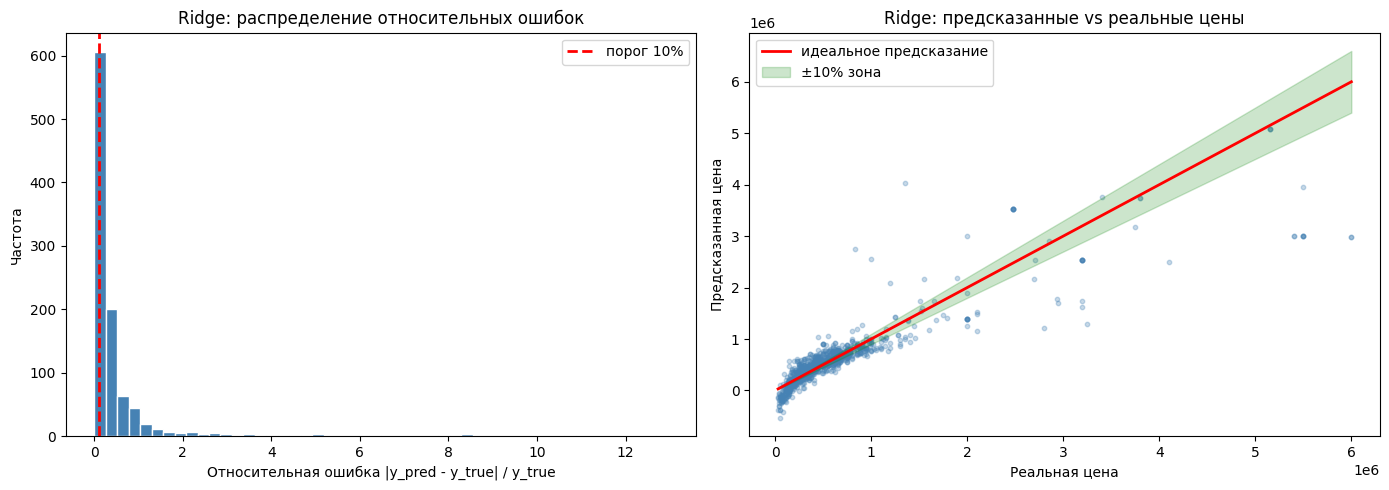

In [176]:
def business_metric(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    relative_error = np.abs(y_pred - y_true) / y_true

    return (relative_error <= 0.10).mean()


# Считаем для всех моделей 

print(f"{'Модель':<30} {'Train':>10} {'Test':>10}")
print("-" * 52)

all_models = [
    ("LinearRegression ",   y_train_pred,        y_test_pred),
    ("Lasso best ",         y_train_pred_best,   y_test_pred_best),
    ("ElasticNet best ",    y_train_pred_en,     y_test_pred_en),
    ("Ridge best ", y_train_pred_ridge,  y_test_pred_ridge),
]

for name, y_tr, y_te in all_models:
    bm_train = business_metric(y_train, y_tr)
    bm_test  = business_metric(y_test,  y_te)
    print(f"{name:<30} {bm_train:>10.4f} {bm_test:>10.4f}")


# Визуализация 
# Посмотрим распределение относительных ошибок для лучшей модели
rel_errors = np.abs(y_test_pred_ridge - y_test) / y_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма относительных ошибок
axes[0].hist(rel_errors, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0.10, color="red", linestyle="--", linewidth=2, label="порог 10%")
axes[0].set_xlabel("Относительная ошибка |y_pred - y_true| / y_true")
axes[0].set_ylabel("Частота")
axes[0].set_title("Ridge: распределение относительных ошибок")
axes[0].legend()

# Предсказанные vs реальные цены
axes[1].scatter(y_test, y_test_pred_ridge, alpha=0.3, s=10, color="steelblue")
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color="red", linewidth=2, label="идеальное предсказание")
axes[1].fill_between(
    [y_test.min(), y_test.max()],
    [y_test.min() * 0.9, y_test.max() * 0.9],
    [y_test.min() * 1.1, y_test.max() * 1.1],
    alpha=0.2, color="green", label="±10% зона"
)
axes[1].set_xlabel("Реальная цена")
axes[1].set_ylabel("Предсказанная цена")
axes[1].set_title("Ridge: предсказанные vs реальные цены")
axes[1].legend()

plt.tight_layout()

Лучшая модель по бизнес-метрике — Ridge :

Train: 28.2% предсказаний попадают в ±10%
Test: 32.0% — каждый третий автомобиль оценён точно

### **Задание 24 (1 балл)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса



In [178]:
def your_business_metrics(y_true, y_pred, penalt = 0.2):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    relative_error = (y_pred - y_true) / y_true

    loss = np.where(
        relative_error < 0,
        penalt * np.abs(relative_error),  # недопрогноз — двойной штраф
        np.abs(relative_error)            # перепрогноз — обычный штраф
    )

    return loss.mean()

print("Асимметричная метрика (чем меньше — тем лучше)")
print(f"Штраф за недопрогноз: x2\n")
print(f"{'Модель':<30} {'Train':>10} {'Test':>10}")
print("-" * 52)

for name, y_tr, y_te in all_models:
    am_train = your_business_metrics(y_train, y_tr)
    am_test  = your_business_metrics(y_test,  y_te)
    print(f"{name:<30} {am_train:>10.4f} {am_test:>10.4f}")


Асимметричная метрика (чем меньше — тем лучше)
Штраф за недопрогноз: x2

Модель                              Train       Test
----------------------------------------------------
LinearRegression                   0.3373     0.3108
Lasso best                         0.3321     0.3069
ElasticNet best                    0.3338     0.3056
Ridge best                         0.2424     0.2198


Лучшая модель — Ridge с показателем 0.2198 на тесте.  ElasticNet обгоняет Lasso и LinearRegression по асимметричной метрике, хотя по бизнес-метрике ±10% они были равны. Это значит, что ElasticNet реже занижает цены, даже если общая точность чуть хуже.

# **Часть 5 (15.5 баллов) | Создание интерактивного приложения на Streamlit**

### **Задание 25 (11 баллов)**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (3 балла)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (3 балла)
- Визуализировать веса обученной модели (3 балла)

Протестируйте приложение на адекватность и запишите демо работы сервиса (`gif` | `mp4` | …).

### **Задание 26 (4.5 балла). Оформление результатов**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории.

Под результатами понимаем следующее:

---

#### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```
5. **заполненный requirements.txt**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.

**Также необходимо приложить ссылку на развернутое в StreamlitHub приложение.**


### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном
* слабая или неполная аналитика в `.md`-файле
* беспорядок в ноутбуке или неясная логика вычислений
* отсутствие файлов
* невыполнение любых других обязательных требований, указанных в описании задания
* Streamlit-приложение не развернуто / не запускается

## Заключительная часть

Надеемся, вы честно проделали все пункты, а не просто пролистали досюда. Теперь можно отдохнуть и похвалить себя. Но пожалуйста, не стоит награждать себя до того, как закончите работать над домашкой :)


Поделитесь впечатлениями о задании:

    (ваши эмоции от домашней работы)

P.S Удачного кодинга!  
Пейте латте маккиато, пишите красивый Python!!